[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/27_exploratory_data_analysis.ipynb)



# Analyse exploratoire des données (EDA)

Ce notebook change de nature. Jusqu'ici, chaque leçon portait sur une technique.
Ici, on apprend une méthode : comment aborder un vrai jeu de données qu'on
découvre, avant même de penser au modèle.

Le jeu : des données médicales réelles de l'Hôpital Israelita Albert Einstein (São
Paulo), sur le diagnostic du COVID-19. Des données brutes, trouées, complexes comme dans la vraie vie. L'objectif de l'EDA est de les comprendre avant de
modéliser.

## Objectif

Comprendre du mieux possible nos données *un petit pas en avant vaut mieux qu'un
grand pas en arrière*. Puis développer une première stratégie de modélisation.

## La checklist en deux temps

Analyse de la forme, la structure du jeu : cible, dimensions, types,
valeurs manquantes.

Analyse du fond, le sens : la cible, les distributions, les relations entre
variables et target.

Cette checklist est la vraie valeur du notebook : une démarche reproductible,
applicable à n'importe quel jeu de données.

Prérequis : les notebooks 17 à 26 (Pandas, visualisation, prétraitement).

## Chargement des données

Le fichier vient de Kaggle. On le téléverse dans Colab, puis on le lit.

In [3]:
from google.colab import files
uploaded = files.upload()  # choisir dataset.xlsx

Saving dataset.xlsx to dataset.xlsx


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Afficher toutes les colonnes malgré leur nombre
pd.set_option('display.max_row', 111)
pd.set_option('display.max_columns', 111)

In [7]:
data = pd.read_excel('dataset.xlsx')
print('dimensions :', data.shape)
data.head()

dimensions : (5644, 111)


,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Serum Glucose,Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Mycoplasma pneumoniae,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,Neutrophils,Urea,Proteina C reativa mg/dL,Creatinine,Potassium,Sodium,"Influenza B, rapid test","Influenza A, rapid test",Alanine transaminase,Aspartate transaminase,Gamma-glutamyltransferase,Total Bilirubin,Direct Bilirubin,Indirect Bilirubin,Alkaline phosphatase,Ionized calcium,Strepto A,Magnesium,pCO2 (venous blood gas analysis),Hb saturation (venous blood gas analysis),Base excess (venous blood gas analysis),pO2 (venous blood gas analysis),Fio2 (venous blood gas analysis),Total CO2 (venous blood gas analysis),pH (venous blood gas analysis),HCO3 (venous blood gas analysis),Rods #,Segmented,Promyelocytes,Metamyelocytes,Myelocytes,Myeloblasts,Urine - Esterase,Urine - Aspect,Urine - pH,Urine - Hemoglobin,Urine - Bile pigments,Urine - Ketone Bodies,Urine - Nitrite,Urine - Density,Urine - Urobilinogen,Urine - Protein,Urine - Sugar,Urine - Leukocytes,Urine - Crystals,Urine - Red blood cells,Urine - Hyaline cylinders,Urine - Granular cylinders,Urine - Yeasts,Urine - Color,Partial thromboplastin time (PTT),Relationship (Patient/Normal),International normalized ratio (INR),Lactic Dehydrogenase,"Prothrombin time (PT), Activity",Vitamin B12,Creatine phosphokinase (CPK),Ferritin,Arterial Lactic Acid,Lipase dosage,D-Dimer,Albumin,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,-0.140648,not_detected,not_detected,not_detected,not_detected,not_detected,detected,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,-0.619086,1.198059,-0.147895,2.089928,-0.305787,0.862512,negative,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

On travaille toujours sur une copie, jamais sur l'original comme au notebook
17. Ainsi, si on casse quelque chose, on recharge sans re-télécharger.

In [8]:
df = data.copy()

## 1. Analyse de la forme

### La check-list de forme

| Élément | Constat |
|---|---|
| Variable cible | `SARS-Cov-2 exam result` |
| Lignes / colonnes | 5644, 111 |
| Types | qualitatives : 70, quantitatives : 41 |
| Valeurs manquantes | beaucoup de NaN (moitié des variables > 90 %) |
| | 2 groupes : 76 % → test viral, 89 % → taux sanguins |

Chaque point se vérifie en une ligne de code. C'est le squelette de toute EDA.

### Dimensions et types

In [9]:
print('dimensions :', df.shape)
df.dtypes.value_counts()

dimensions : (5644, 111)


,count
float64,70
object,37
int64,4


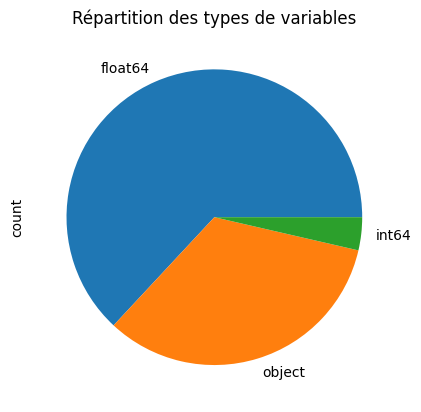

In [10]:
df.dtypes.value_counts().plot.pie()
plt.title('Répartition des types de variables')
plt.show()

On a une majorité de variables `float` (les mesures sanguines continues) et des
variables `object` (les tests viraux, textuels). Le camembert donne une vue
immédiate de la composition du jeu.

### Les valeurs manquantes : le cœur de ce dataset

C'est le défi de ces données médicales. On les visualise avec une heatmap.

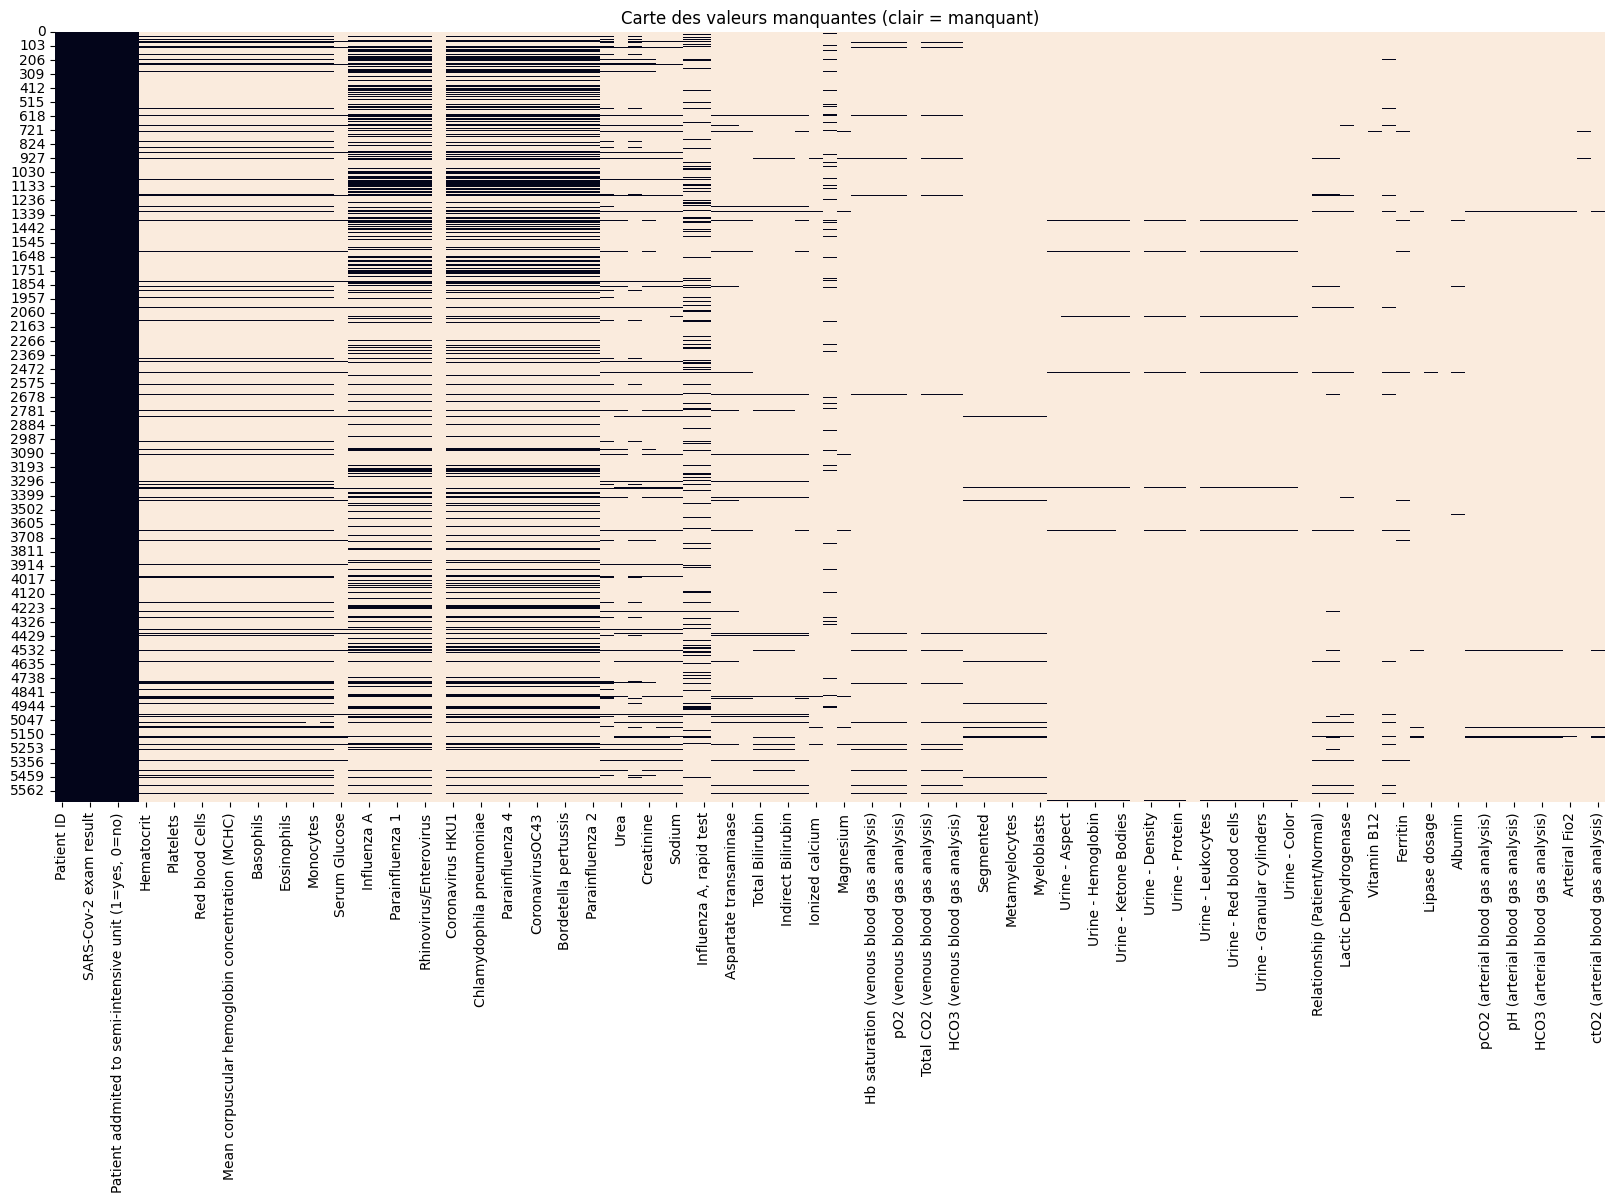

In [11]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.isna(), cbar=False)
plt.title('Carte des valeurs manquantes (clair = manquant)')
plt.show()

Comment lire cette carte. Chaque colonne du dataset est une colonne de la
heatmap ; chaque ligne, un patient. Les zones claires sont les valeurs
manquantes.

Deux choses sautent aux yeux. D'abord, l'immense majorité est claire le jeu est
troué à l'extrême. Ensuite, les manques forment des blocs verticaux : des
groupes de variables sont renseignés ou absents ensemble. C'est un indice
majeur ces groupes correspondent à des types d'examens prescrits ensemble.

### Quantifier les manques

In [12]:
taux_manquant = df.isna().sum() / df.shape[0]
taux_manquant.sort_values(ascending=False).head(20)

,0
Mycoplasma pneumoniae,1.000000
"Prothrombin time (PT), Activity",1.000000
D-Dimer,1.000000
Urine - Sugar,1.000000
Partial thromboplastin time (PTT),1.000000
Urine - Nitrite,0.999823
Fio2 (venous blood gas analysis),0.999823
Vitamin B12,0.999468
Lipase dosage,0.998583
Albumin,0.997697


Beaucoup de colonnes dépassent 90 % de NaN. Comme tu l'as noté : deux grands
groupes se dessinent autour de 76 % pour les tests viraux, 89 % pour les
taux sanguins. Ces deux blocs correspondent aux blocs verticaux de la heatmap.

### Éliminer les colonnes trop vides

Une variable à 95 % de NaN est inexploitable. On garde celles remplies à plus de
10 % (moins de 90 % de NaN).

In [13]:
df = df[df.columns[taux_manquant < 0.9]]
print('colonnes restantes :', df.shape[1])

colonnes restantes : 39


In [14]:
# Retirer l'identifiant patient, inutile pour la modélisation
df = df.drop('Patient ID', axis=1)
df.head()

,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,"Influenza B, rapid test","Influenza A, rapid test"
0,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,negative,negative
2,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,NaN,NaN


`Patient ID` est un identifiant unique aucune valeur prédictive, on le retire
comme au notebook 17. On passe de 111 à un nombre de colonnes bien plus
raisonnable, en ne gardant que ce qui est exploitable.

## 2. Analyse du fond

### La check-list de fond

| Élément | Constat |
|---|---|
| Visualisation de la cible | 10 % de positifs (558 / 5000) |
| Signification des variables | continues standardisées, asymétriques (sang) |
| | age en quantile, difficile à interpréter |
| | qualitatives binaires (viral), Rhinovirus élevé |
| Relation variables / cible | Monocytes, Platelets, Leukocytes liés au COVID ? |
| | faible âge peu contaminé ? (prudence) |
| | doubles maladies rares |

### Visualiser la cible

In [15]:
df['SARS-Cov-2 exam result'].value_counts()

,count
SARS-Cov-2 exam result,
negative,5086
positive,558


In [16]:
df['SARS-Cov-2 exam result'].value_counts(normalize=True)

,proportion
SARS-Cov-2 exam result,
negative,0.901134
positive,0.098866


Les classes sont déséquilibrées : environ 10 % de positifs, 90 % de
négatifs. C'est capital pour la suite.

Ce déséquilibre change tout, comme vu au notebook 21.1 : un modèle qui prédit
« négatif » pour tout le monde aurait déjà 90 % d'exactitude, sans rien
comprendre. Il faudra donc une validation stratifiée et des métriques adaptées
(pas seulement l'accuracy). Le déséquilibre est le premier fait à retenir pour la
stratégie de modélisation.

### Signification des variables continues

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


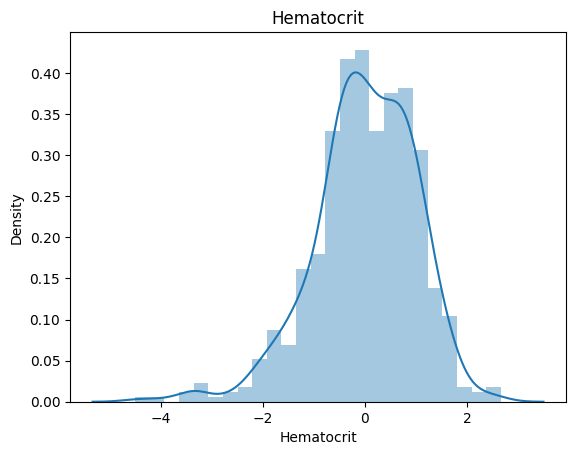

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


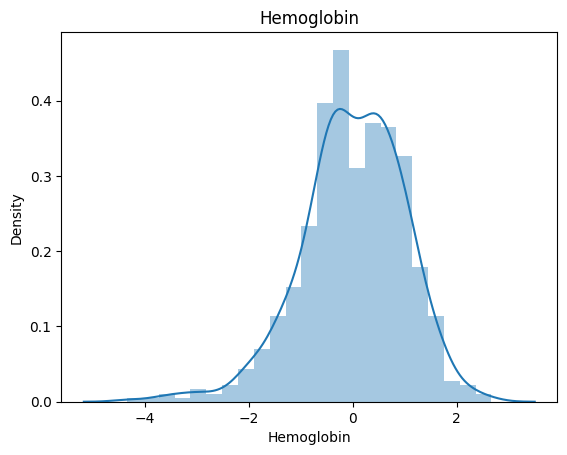

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


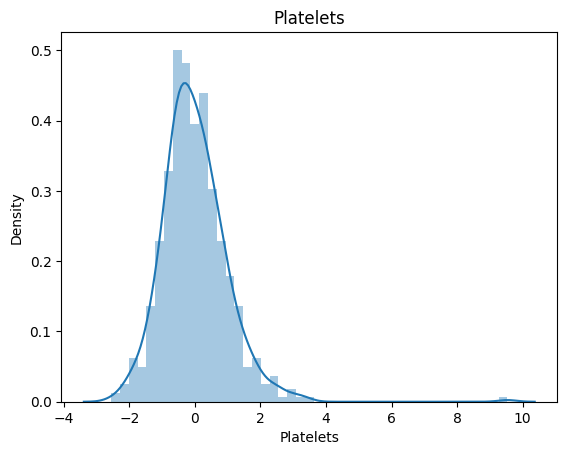

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


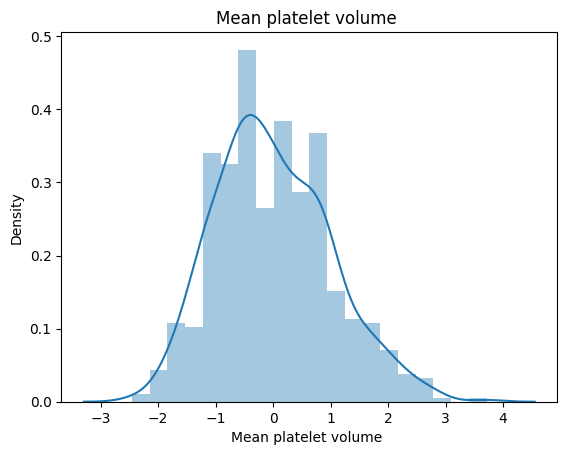

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


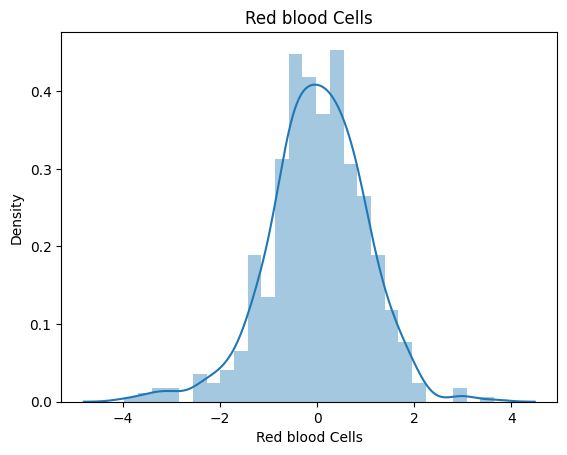

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


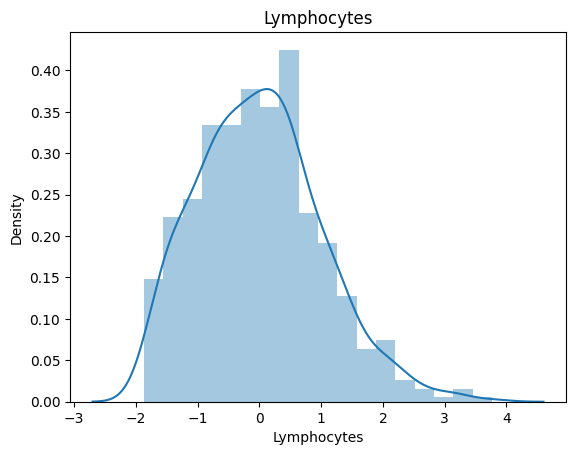

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


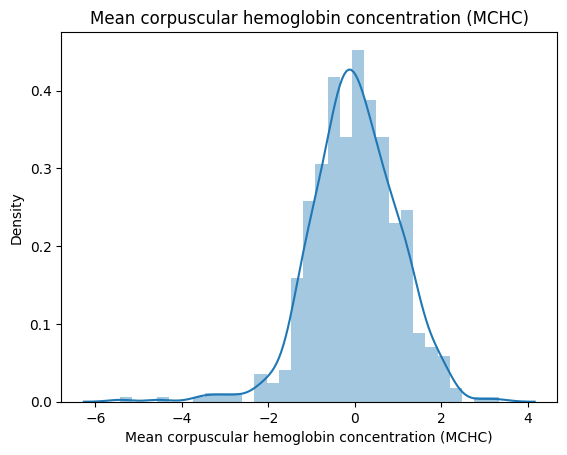

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


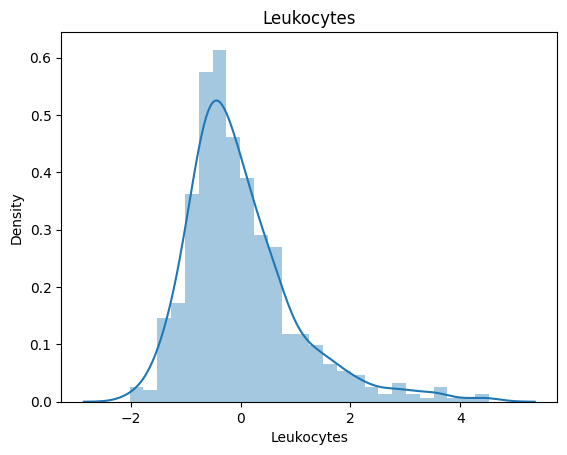

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


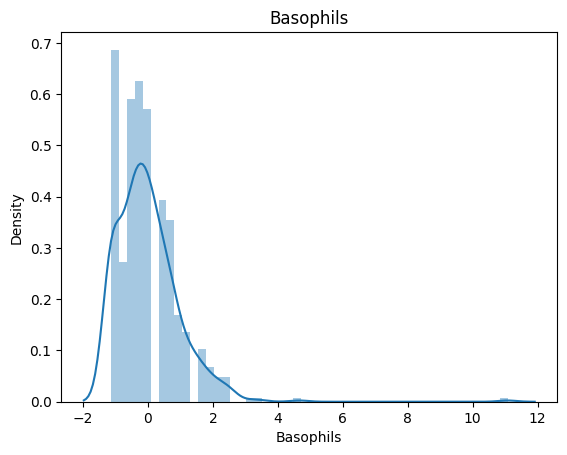

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


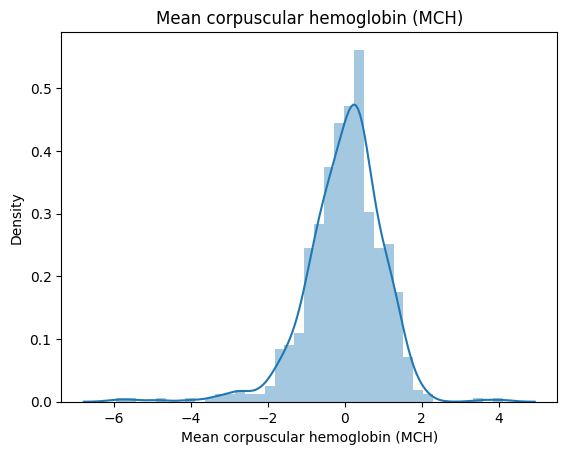

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


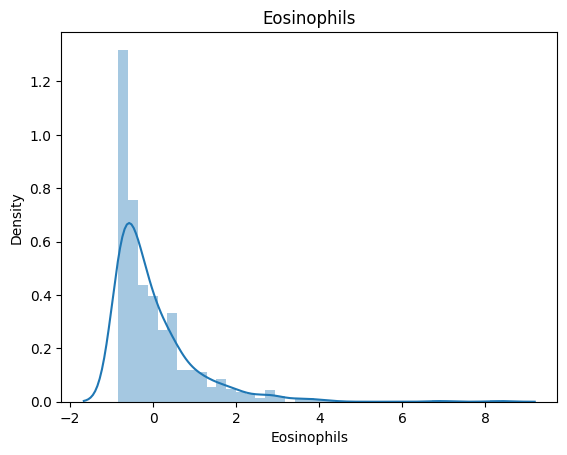

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


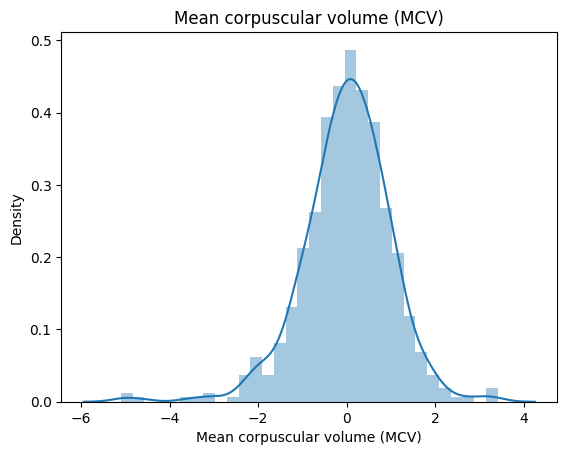

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


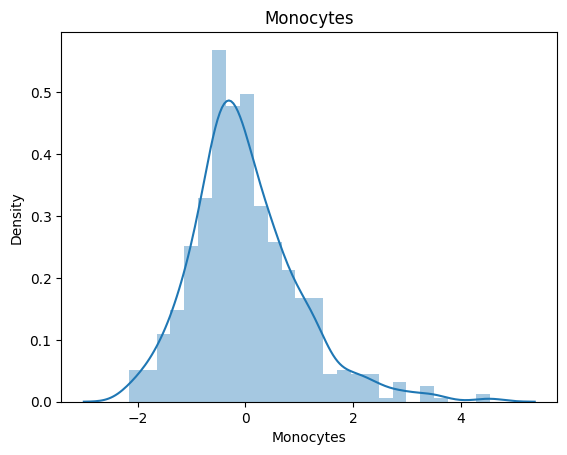

/tmp/ipykernel_1987/2396411412.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


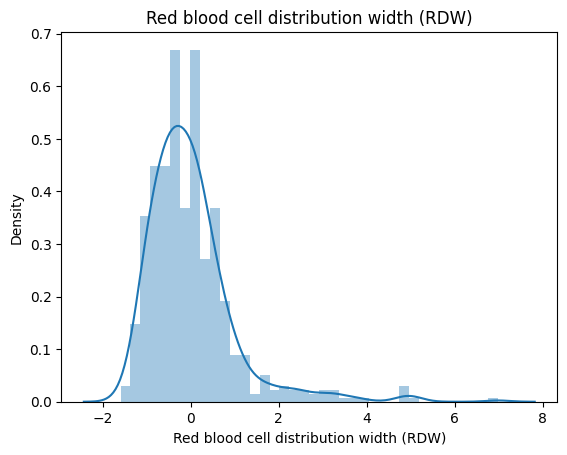

In [17]:
for col in df.select_dtypes('float'):
    plt.figure()
    sns.distplot(df[col])
    plt.title(col)
    plt.show()

Ce que ces graphiques révèlent : les variables sanguines sont standardisées
(centrées sur 0, écart-type 1) le dataset l'annonce, et on le voit à l'axe. Pas
besoin de les re-normaliser, c'est déjà fait.

Elles sont aussi asymétriques (*skewed*), avec des traînes et des valeurs
extrêmes. Sur un jeu médical, ces extrêmes sont souvent de vrais cas rares, pas des
erreurs à ne pas supprimer sans réfléchir.

### La variable âge

/tmp/ipykernel_1987/2351841816.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Patient age quantile'])


,count
Patient age quantile,
11,380
4,366
9,359
0,334
7,319
2,315
13,313
14,299
5,294


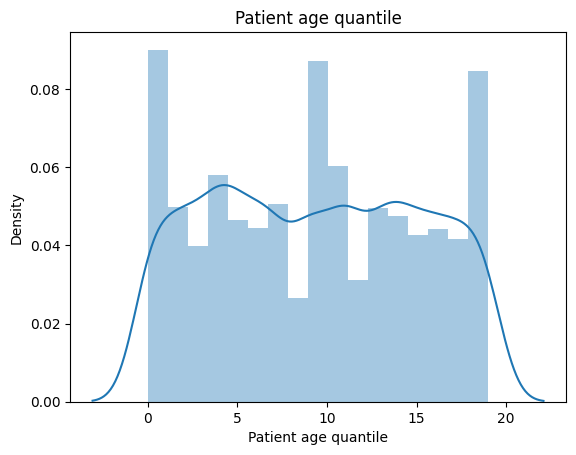

In [18]:
sns.distplot(df['Patient age quantile'])
plt.title("Patient age quantile")
df['Patient age quantile'].value_counts()

`Patient age quantile` est difficile à interpréter, et c'est un bon réflexe de
le noter. Ces données ont clairement été transformées on pourrait croire que 0
correspond à 0-5 ans, mais ce pourrait être une tout autre transformation
mathématique (un *quantile transformer*, par exemple). La personne qui a publié le
dataset ne le précise nulle part, donc on ne peut pas savoir.

Ce n'est pas grave : l'important est de savoir qu'on ne connaît pas l'échelle
réelle de l'âge, ce qui invite à la prudence dans l'interprétation. La variable
reste utile pour la comparer aux taux sanguins.

### Les variables qualitatives

In [19]:
for col in df.select_dtypes('object'):
    print(f'{col:-<50} {df[col].unique()}')

SARS-Cov-2 exam result---------------------------- ['negative' 'positive']
Respiratory Syncytial Virus----------------------- [nan 'not_detected' 'detected']
Influenza A--------------------------------------- [nan 'not_detected' 'detected']
Influenza B--------------------------------------- [nan 'not_detected' 'detected']
Parainfluenza 1----------------------------------- [nan 'not_detected' 'detected']
CoronavirusNL63----------------------------------- [nan 'not_detected' 'detected']
Rhinovirus/Enterovirus---------------------------- [nan 'detected' 'not_detected']
Coronavirus HKU1---------------------------------- [nan 'not_detected' 'detected']
Parainfluenza 3----------------------------------- [nan 'not_detected' 'detected']
Chlamydophila pneumoniae-------------------------- [nan 'not_detected' 'detected']
Adenovirus---------------------------------------- [nan 'not_detected' 'detected']
Parainfluenza 4----------------------------------- [nan 'not_detected' 'detected']
Coronavirus2

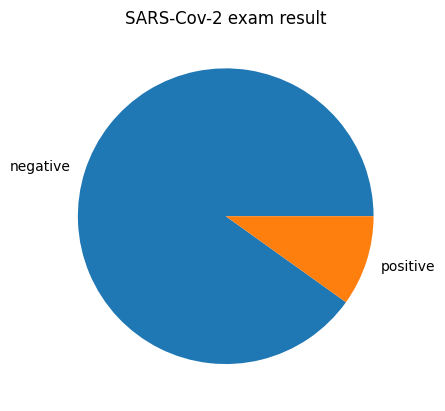

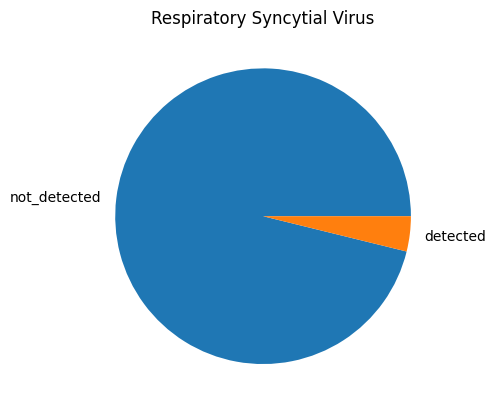

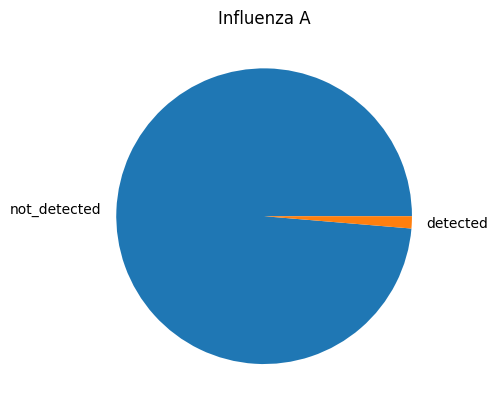

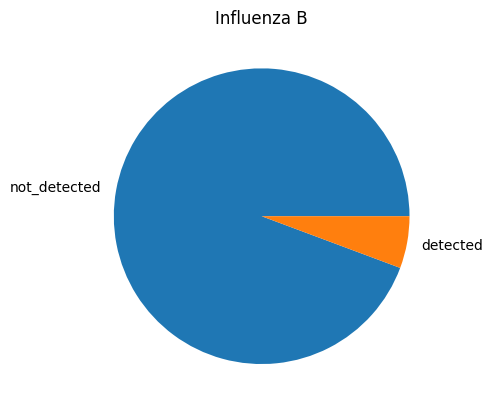

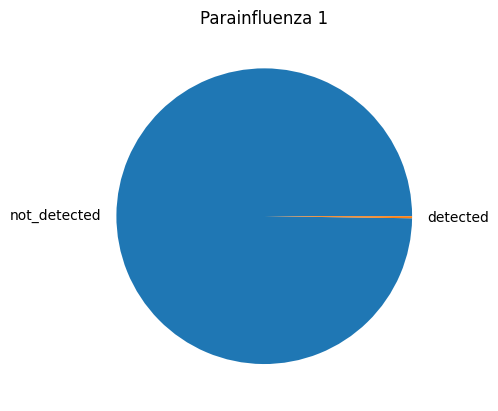

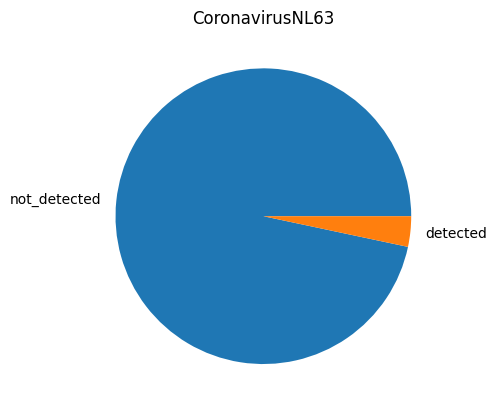

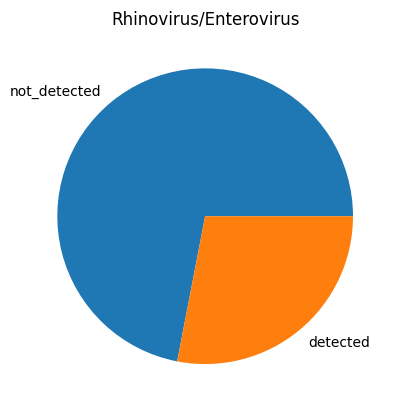

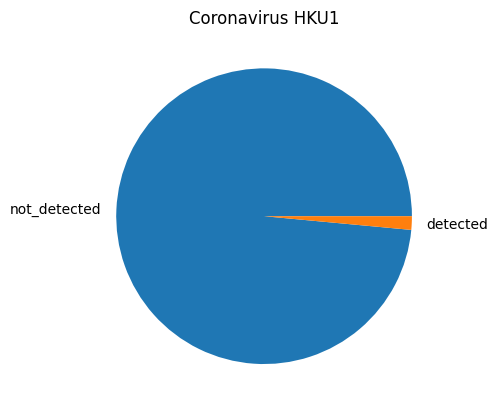

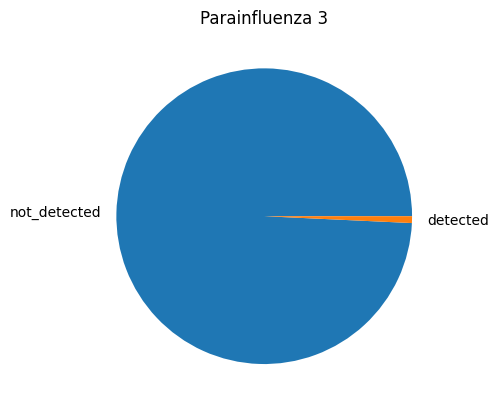

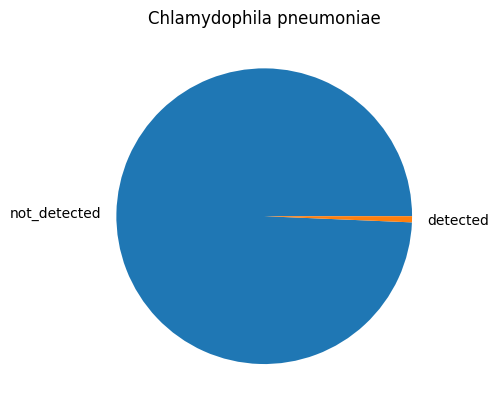

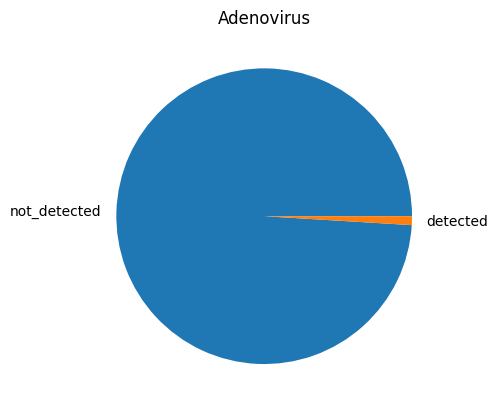

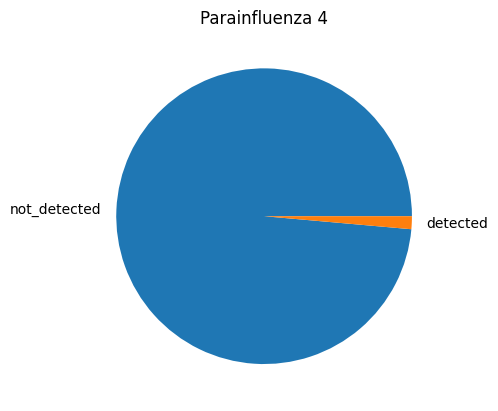

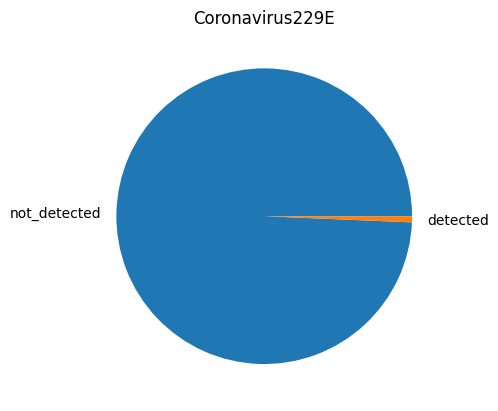

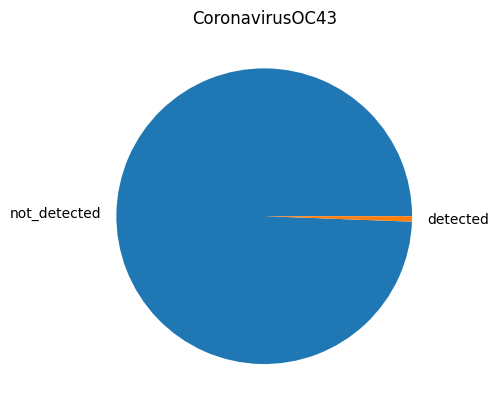

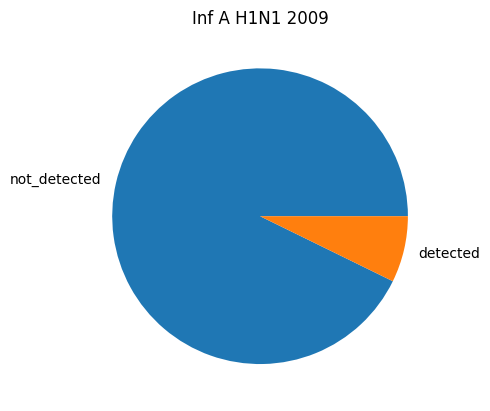

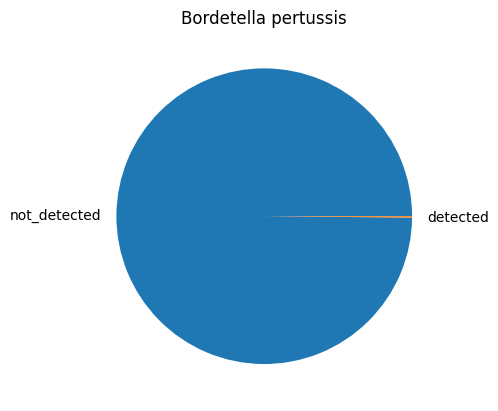

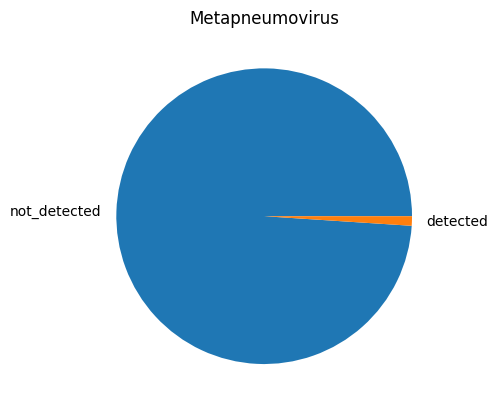

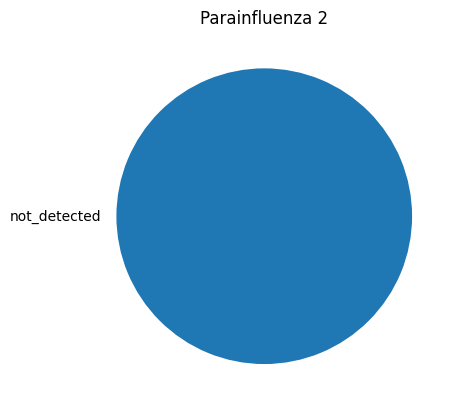

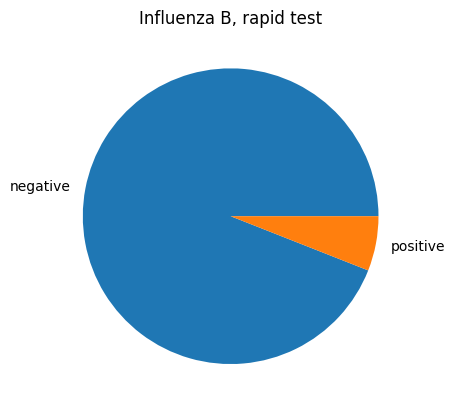

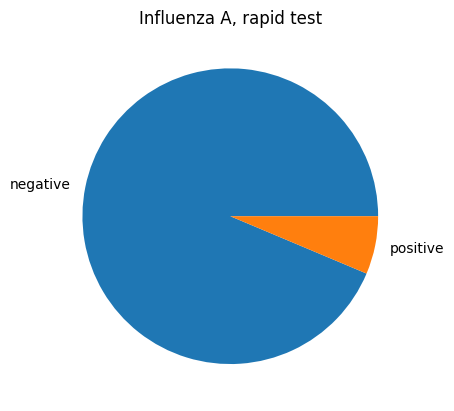

In [20]:
for col in df.select_dtypes('object'):
    plt.figure()
    df[col].value_counts().plot.pie()
    plt.title(col)
    plt.ylabel('')
    plt.show()

Toutes les variables qualitatives sont binaires `detected`/`not_detected`,
`positive`/`negative`. Ce sont des tests viraux.

Parmi elles, le Rhinovirus ressort avec un taux détecté élevé. À garder en
tête : la région a peut-être connu une épidémie de rhinovirus concurrente au
COVID.

## 3. Relation entre les variables et la cible

C'est le cœur de l'EDA : quelles variables sont liées au fait d'être positif au
COVID ? On sépare les patients en deux groupes et on compare.

In [21]:
positive_df = df[df['SARS-Cov-2 exam result'] == 'positive']
negative_df = df[df['SARS-Cov-2 exam result'] == 'negative']

print('positifs :', positive_df.shape[0])
print('négatifs :', negative_df.shape[0])

positifs : 558
négatifs : 5086


### Créer les groupes de variables

Les blocs de la heatmap suggéraient des groupes. On les définit par leur taux de
NaN : autour de 89 % pour le sang, entre 75 et 88 % pour le viral.

In [22]:
taux_manquant = df.isna().sum() / df.shape[0]

blood_columns = df.columns[(taux_manquant < 0.9) & (taux_manquant > 0.88)]
viral_columns = df.columns[(taux_manquant < 0.88) & (taux_manquant > 0.75)]

print('variables sanguines :', len(blood_columns))
print('variables virales :', len(viral_columns))

variables sanguines : 14
variables virales : 19


### Cible et taux sanguins

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


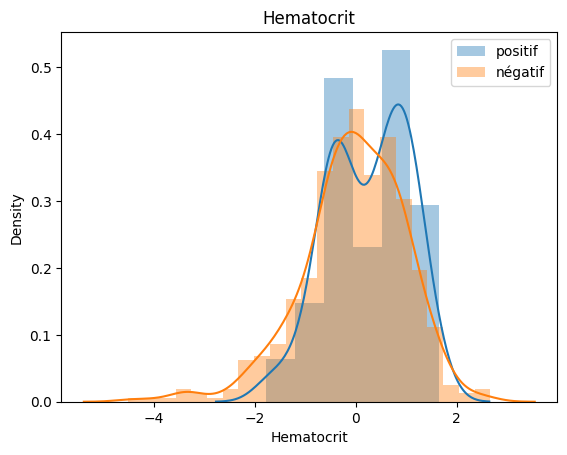

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


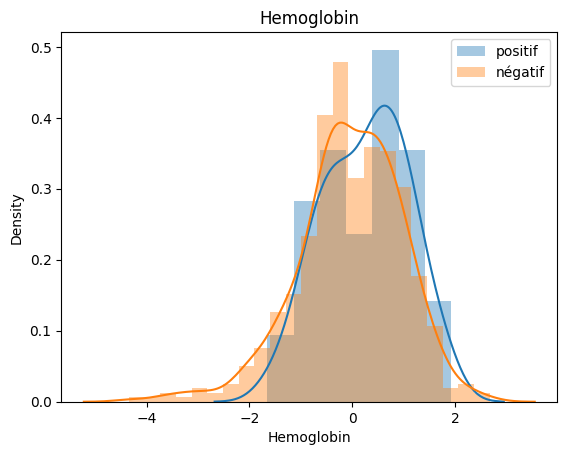

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


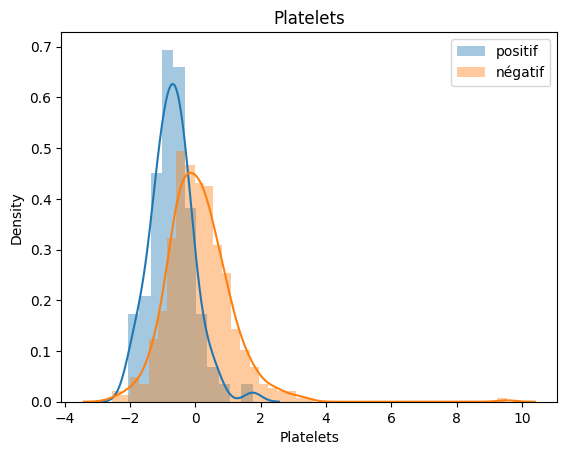

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


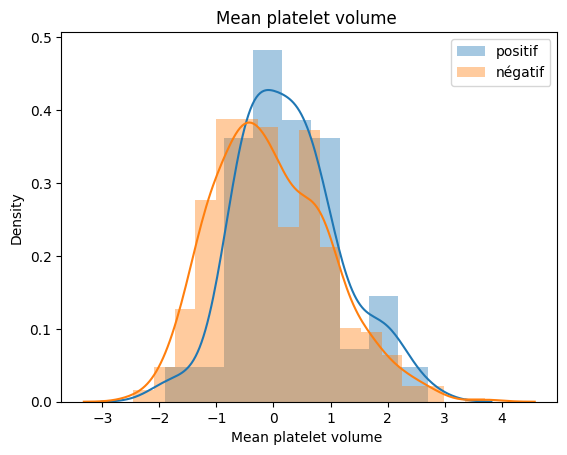

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


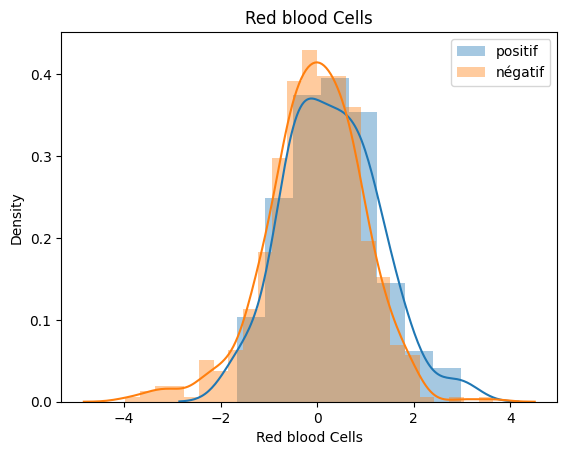

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


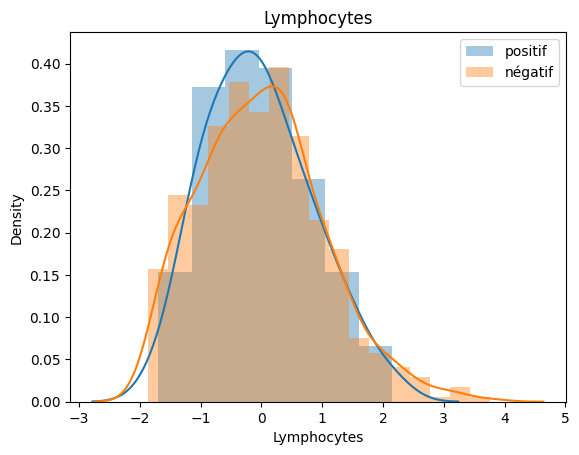

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


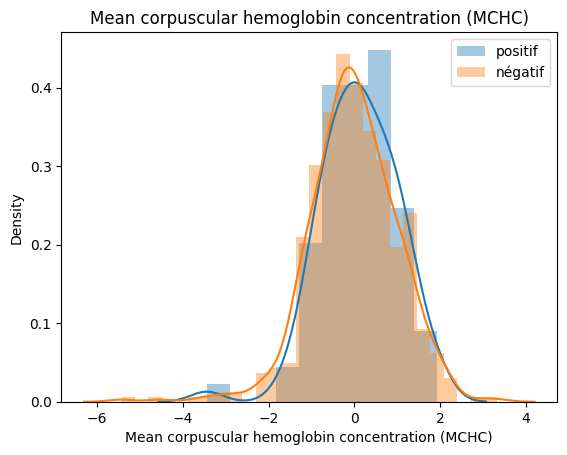

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


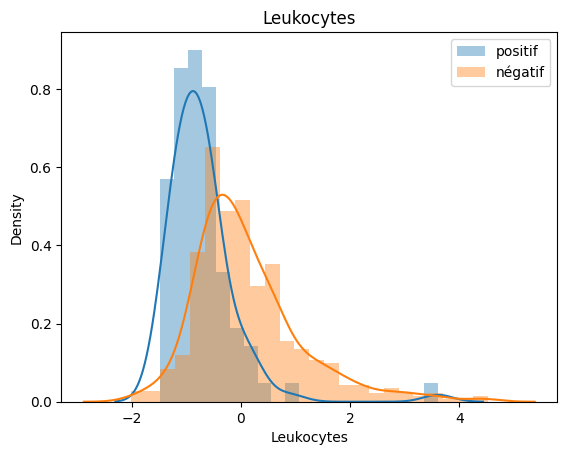

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


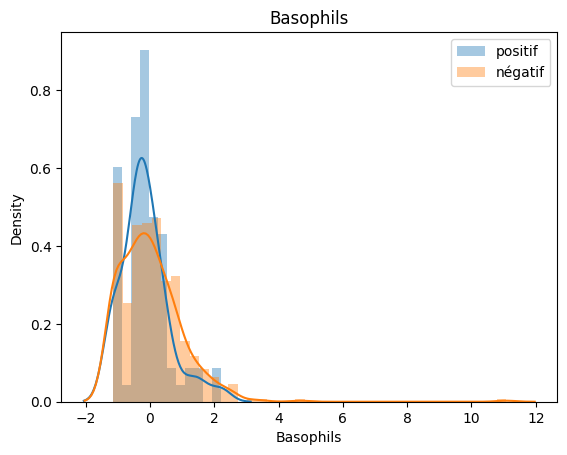

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


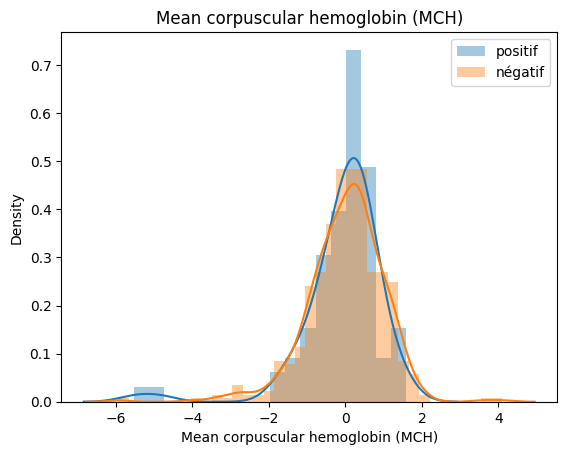

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


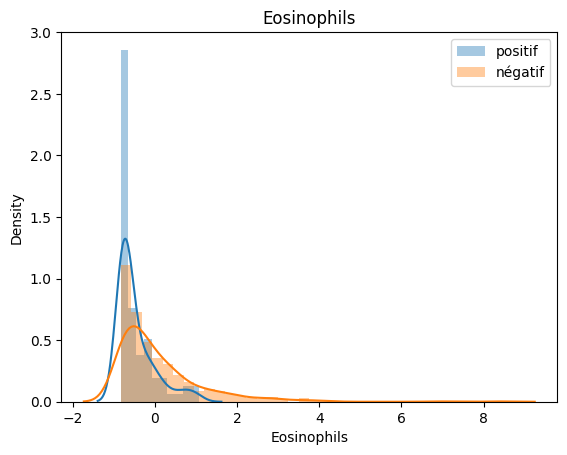

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


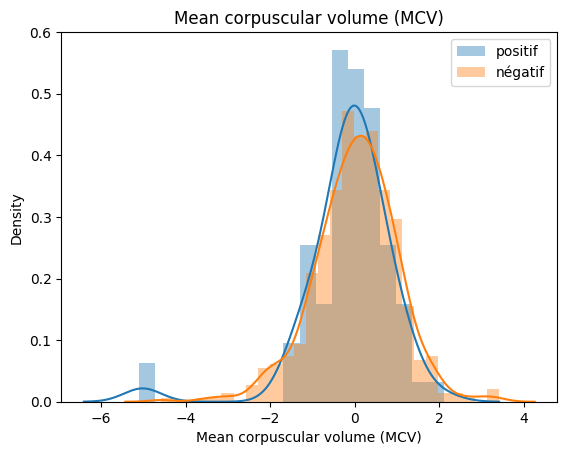

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


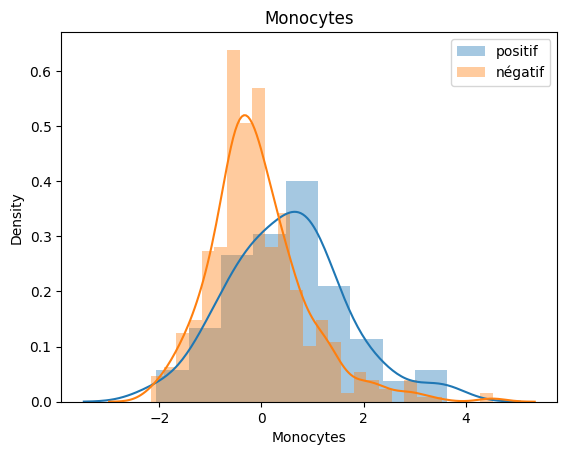

/tmp/ipykernel_1987/1791807807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(positive_df[col], label='positif')
/tmp/ipykernel_1987/1791807807.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(negative_df[col], label='négatif')


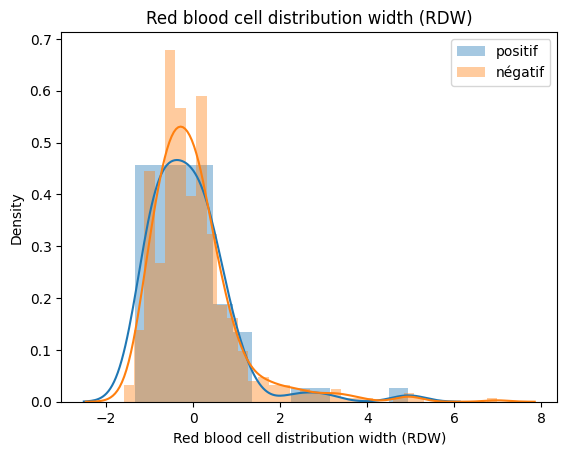

In [23]:
for col in blood_columns:
    plt.figure()
    sns.distplot(positive_df[col], label='positif')
    sns.distplot(negative_df[col], label='négatif')
    plt.title(col)
    plt.legend()
    plt.show()

Ce qu'on cherche : les variables où les courbes positive et négative sont décalées. Un décalage = la variable distingue les deux groupes = elle est
prédictive.

Le constat, ta première hypothèse : les taux de Monocytes, Platelets et Leukocytes semblent liés au COVID-19 leurs distributions diffèrent entre
positifs et négatifs. C'est une hypothèse à tester rigoureusement plus loin,
pas encore une conclusion.

### Cible et âge

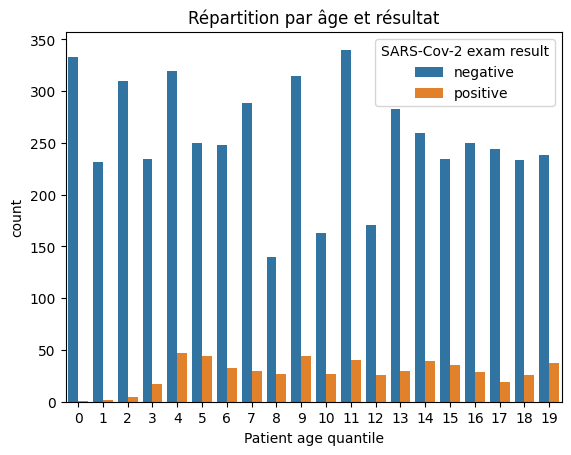

In [24]:
sns.countplot(x='Patient age quantile', hue='SARS-Cov-2 exam result', data=df)
plt.title('Répartition par âge et résultat')
plt.show()

Le constat, avec sa nuance essentielle : les individus de faible âge semblent
peu contaminés. Mais prudence et c'est un raisonnement de bon épidémiologiste.

On ne connaît pas la vraie échelle de l'âge (transformation en quantile). On ne
sait pas non plus de quand date le dataset. Et surtout : s'il s'agissait
d'enfants, on sait qu'ils sont touchés autant que les adultes. Donc ce constat
brut ne prouve rien sur le lien âge / COVID.

En revanche, la variable âge restera utile pour croiser avec les taux sanguins c'est là qu'elle apportera de l'information.

### Cible et tests viraux

In [25]:
pd.crosstab(df['SARS-Cov-2 exam result'], df['Influenza A'])

Influenza A,detected,not_detected
SARS-Cov-2 exam result,,
negative,18,1224
positive,0,112


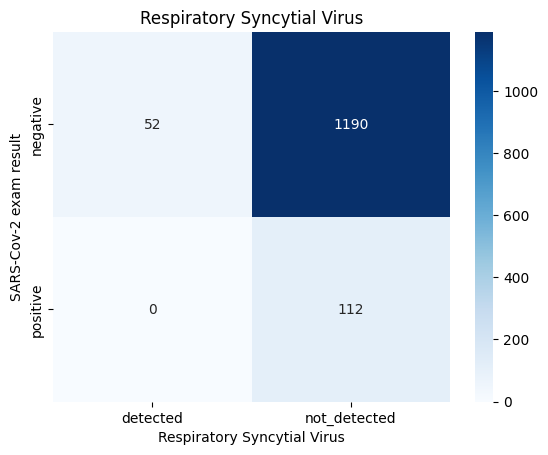

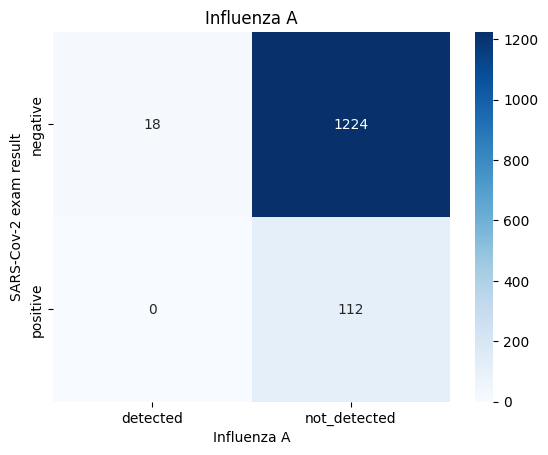

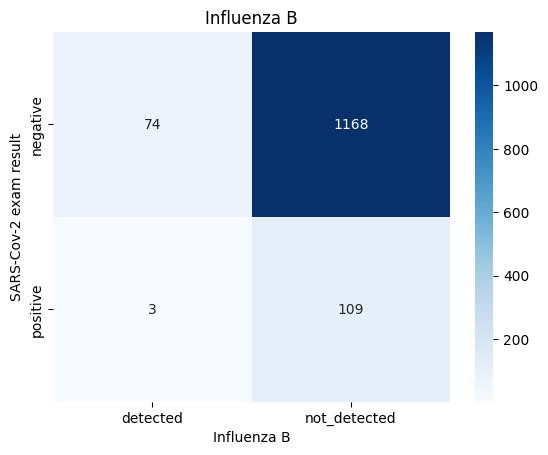

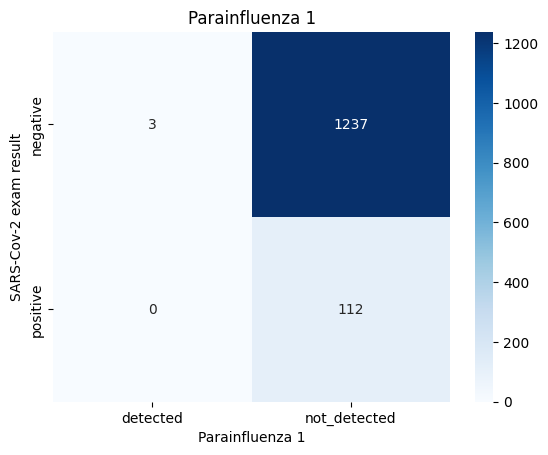

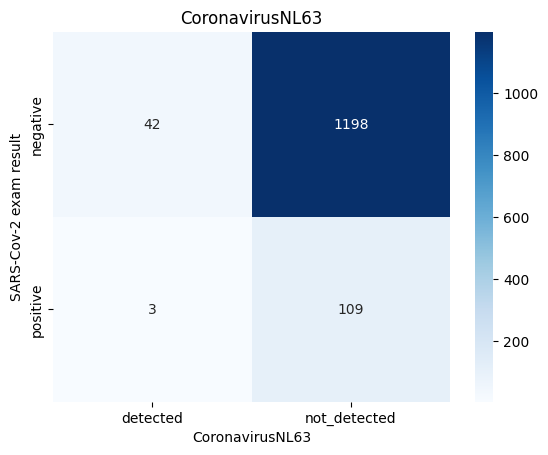

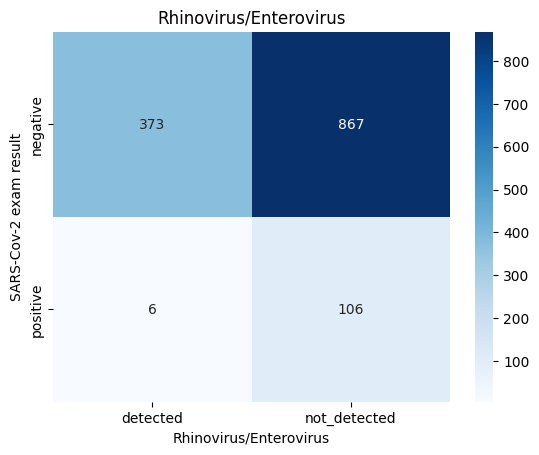

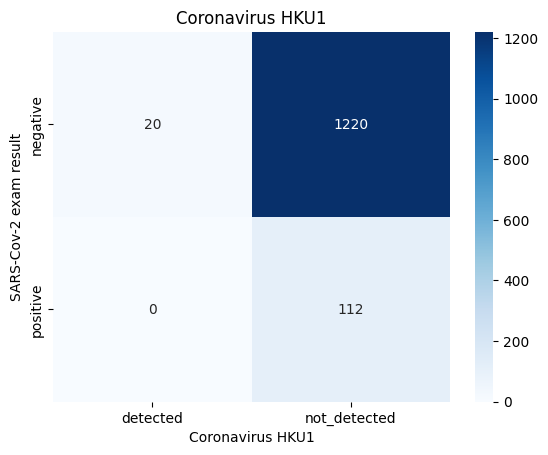

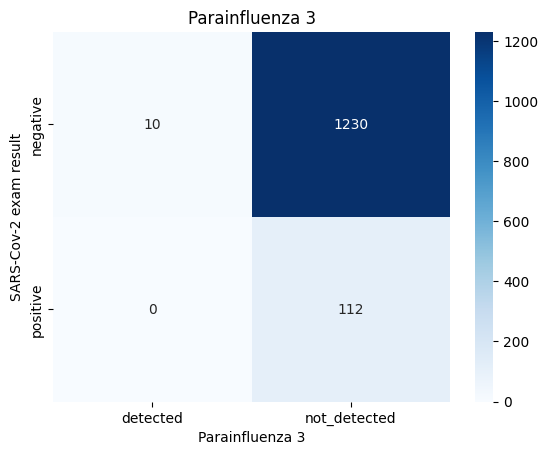

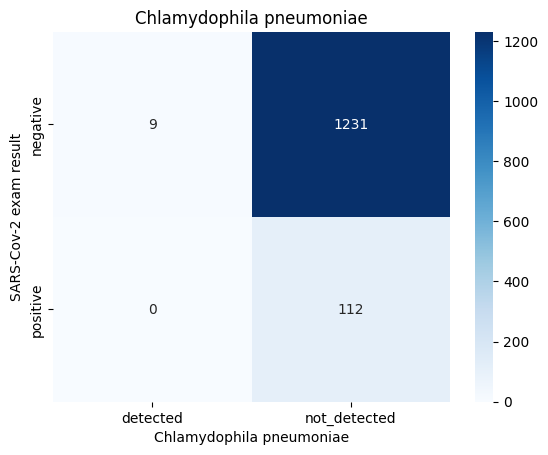

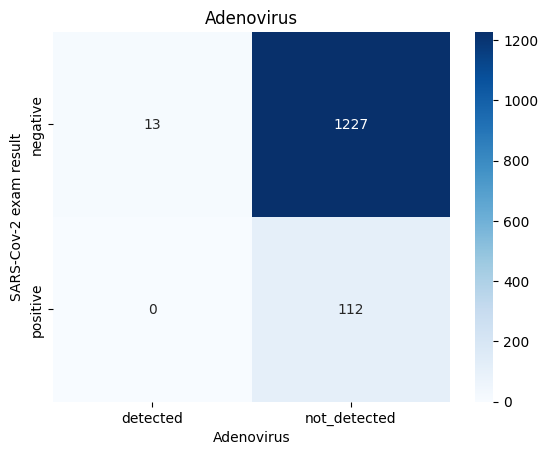

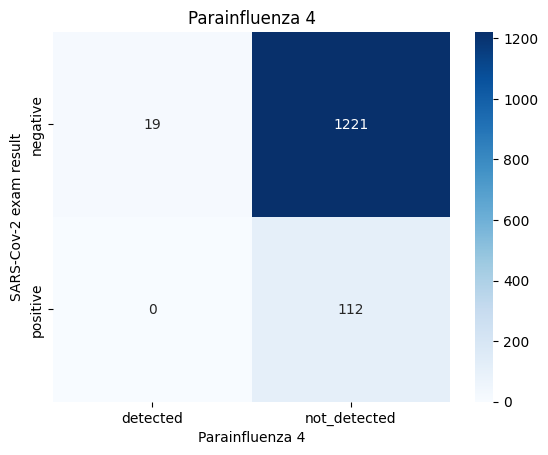

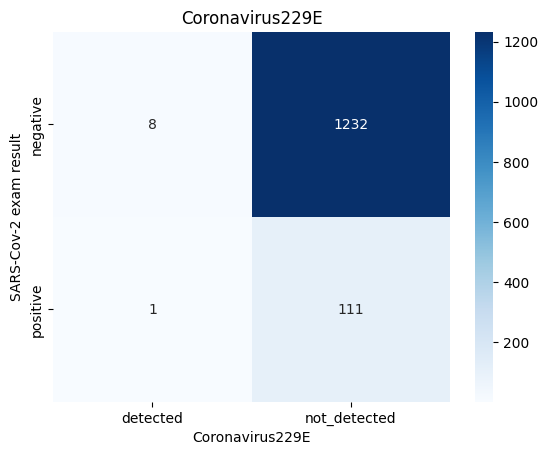

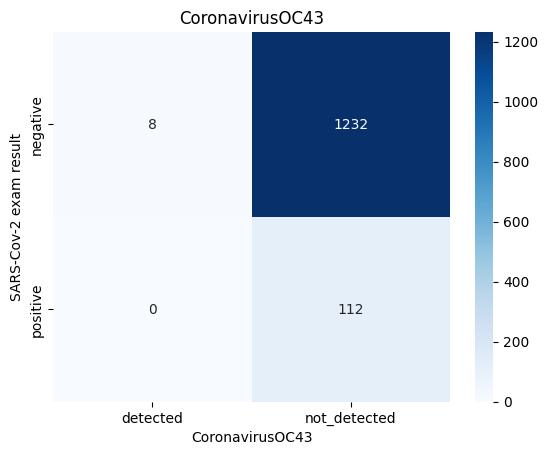

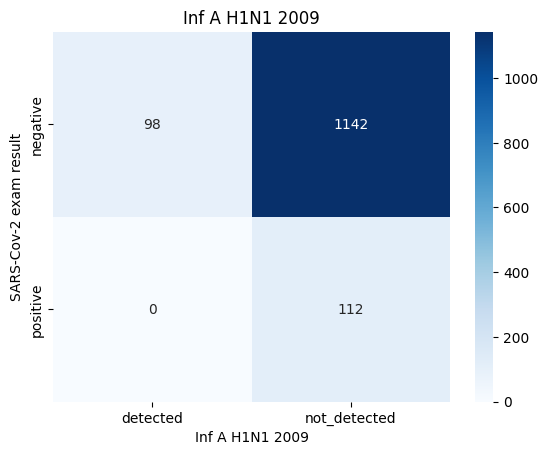

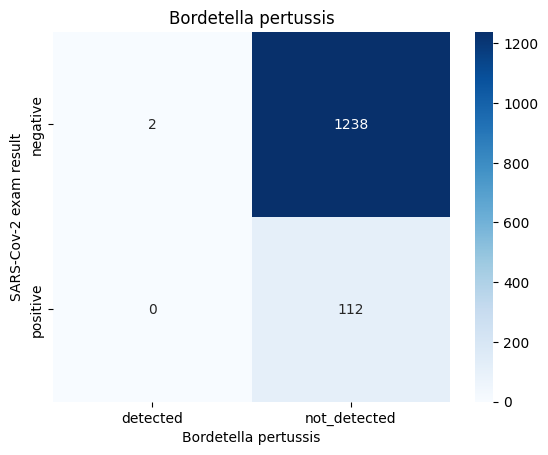

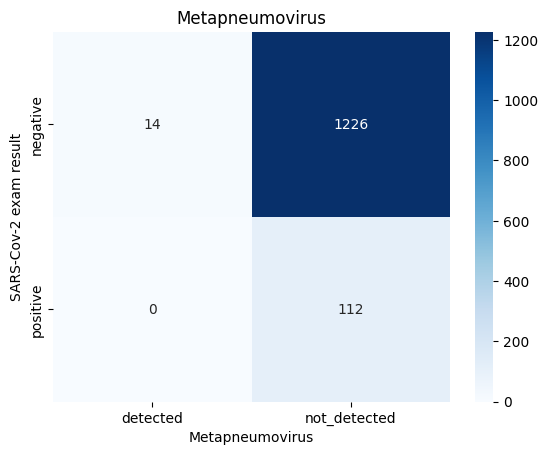

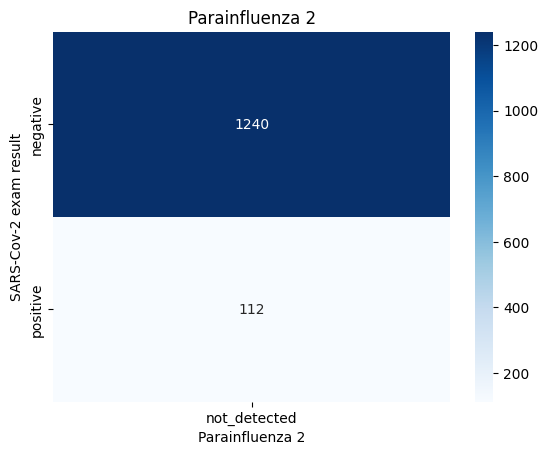

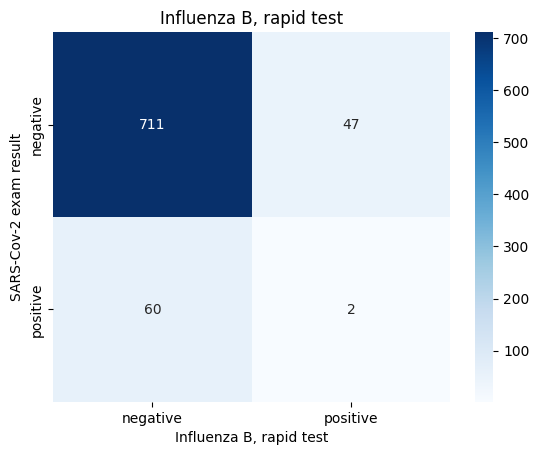

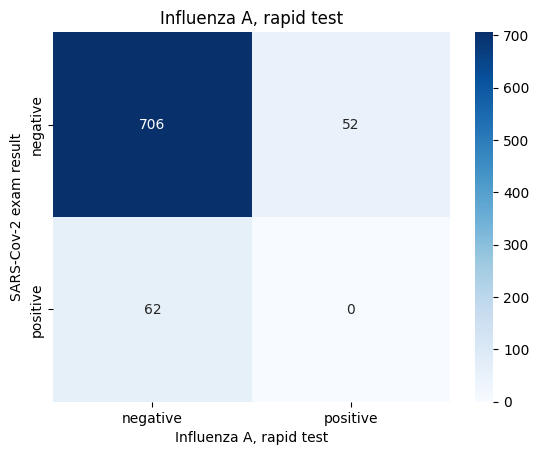

In [26]:
for col in viral_columns:
    plt.figure()
    sns.heatmap(pd.crosstab(df['SARS-Cov-2 exam result'], df[col]),
                annot=True, fmt='d', cmap='Blues')
    plt.title(col)
    plt.show()

Un `crosstab` compte les combinaisons ici combien de positifs/négatifs COVID
pour chaque test viral détecté ou non. La heatmap le rend visuel.

Le constat, encore avec prudence : les doubles maladies sont rares. On voit
peu de patients positifs à la fois au COVID et à un autre virus.

Attention à l'interprétation d'un « Rhinovirus positif → COVID négatif ». C'est une hypothèse à tester, pas un fait. Il est très possible que la région ait connu
une épidémie de rhinovirus, et on peut parfaitement avoir deux virus en même temps.
Ce constat n'a peut-être aucun lien causal avec le COVID.

## 4. Analyse détaillée : variables entre elles

Après le lien avec la cible, on examine les liens entre variables.

### Taux sanguins entre eux

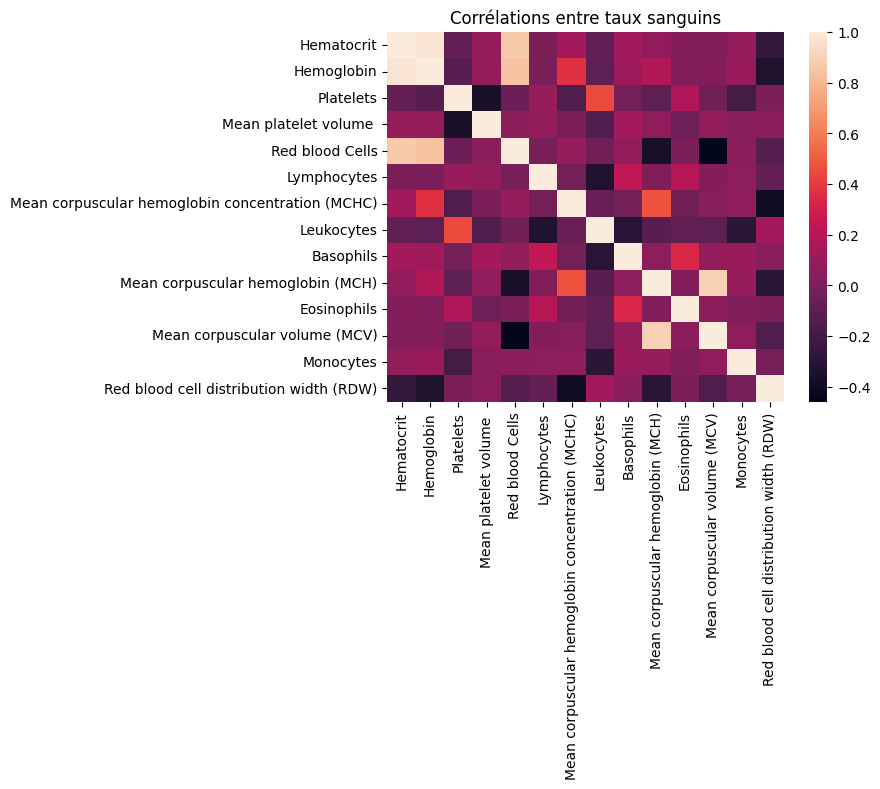

In [27]:
sns.heatmap(df[blood_columns].corr())
plt.title('Corrélations entre taux sanguins')
plt.show()

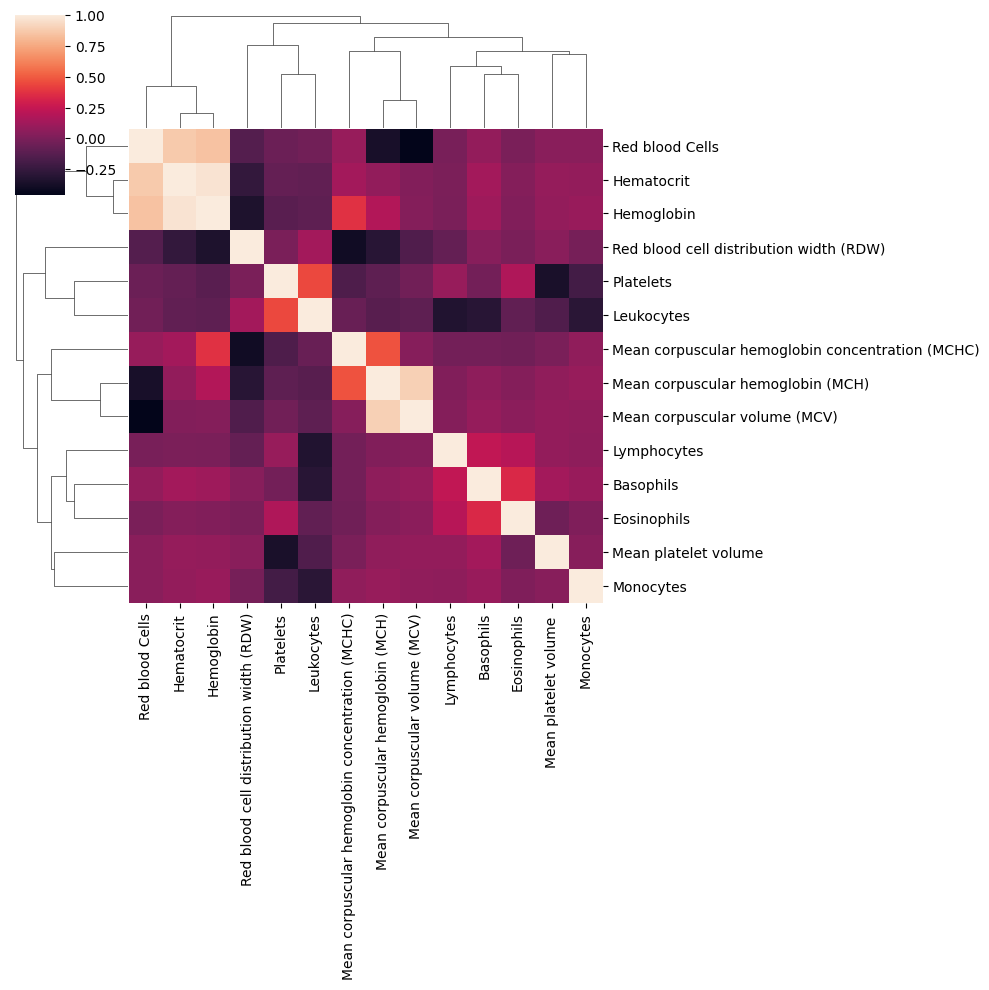

In [28]:
sns.clustermap(df[blood_columns].corr())
plt.show()

Le constat : certaines variables sanguines sont très corrélées (jusqu'à
+0,9). Le `clustermap` regroupe automatiquement les variables liées il réorganise
la matrice pour rapprocher ce qui se ressemble.

Cette forte corrélation est à surveiller plus tard : deux variables à 0,9 de
corrélation disent presque la même chose. On pourra en retirer une (sélection de
variables du notebook 23) sans perdre d'information.

### Taux sanguins et âge

In [29]:
df.corr(numeric_only=True)['Patient age quantile'].sort_values()

,Patient age quantile
Leukocytes,-0.166386
Platelets,-0.158683
Lymphocytes,-0.125935
Mean corpuscular hemoglobin concentration (MCHC),-0.124671
Red blood Cells,-0.037510
"Patient addmited to intensive care unit (1=yes, 0=no)",-0.035772
"Patient addmited to semi-intensive unit (1=yes, 0=no)",0.015736
Eosinophils,0.022085
"Patient addmited to regular ward (1=yes, 0=no)",0.046166
Monocytes,0.050962


Note : `corr(numeric_only=True)` est indispensable sans lui, Pandas tente de
corréler les colonnes texte et lève une `ValueError: could not convert string to
float`.

Le constat : très faible corrélation entre l'âge et les taux sanguins. Les deux
apportent donc des informations indépendantes utile, car des variables non
redondantes enrichissent un modèle.

### Un test qui déçoit

In [30]:
pd.crosstab(df['Influenza A'], df['Influenza A, rapid test'])

"Influenza A, rapid test",negative,positive
Influenza A,,
detected,2,4
not_detected,245,15


Le constat : le test rapide de la grippe donne de mauvais résultats il
concorde mal avec le test de référence. Il faudra peut-être laisser tomber
cette variable : un test peu fiable ajoute du bruit.

### Créer une variable : est malade

In [31]:
# Un patient est "malade" s'il a au moins un virus détecté
df['est malade'] = np.sum(df[viral_columns[:-2]] == 'detected', axis=1) >= 1

malade_df = df[df['est malade'] == True]
non_malade_df = df[df['est malade'] == False]

print('malades :', malade_df.shape[0])
print('non malades :', non_malade_df.shape[0])

malades : 692
non malades : 4952


On crée une variable à partir des autres du feature engineering du notebook
22. `est malade` résume « ce patient a-t-il au moins un virus ? ». On peut ensuite
comparer les taux sanguins des malades et des non-malades.

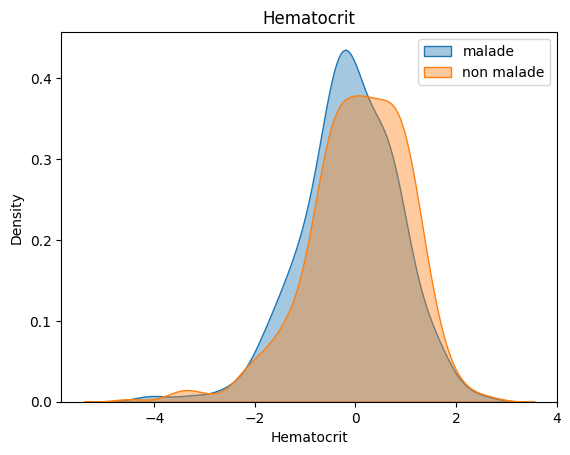

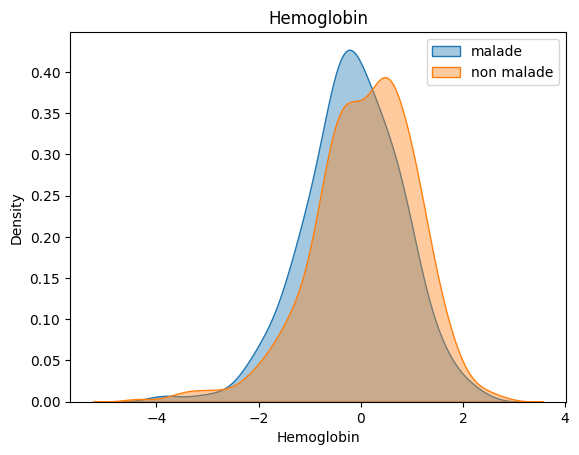

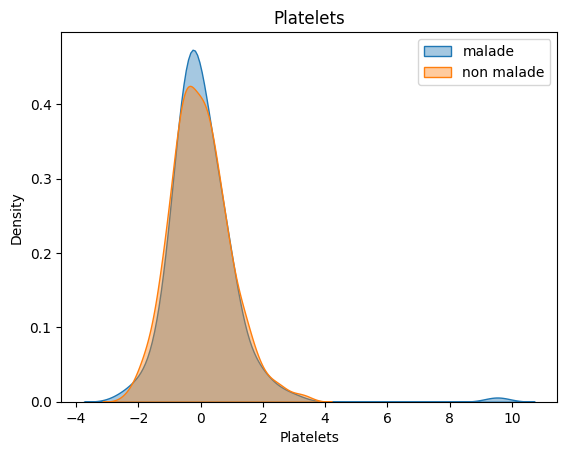

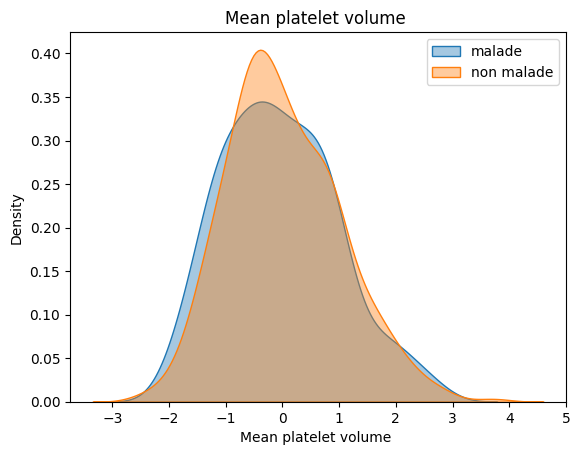

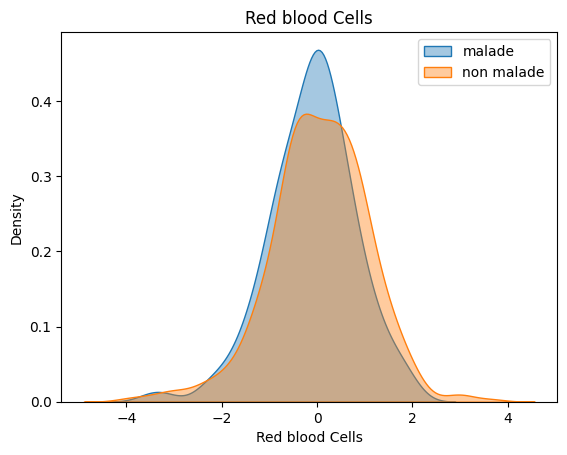

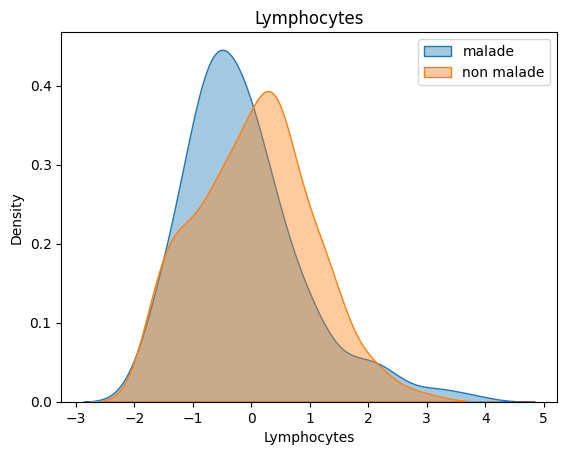

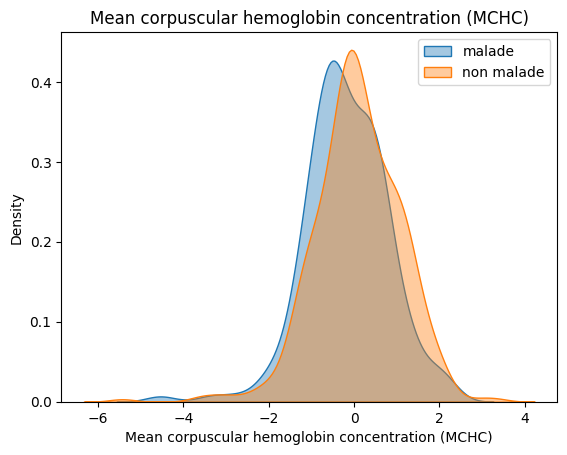

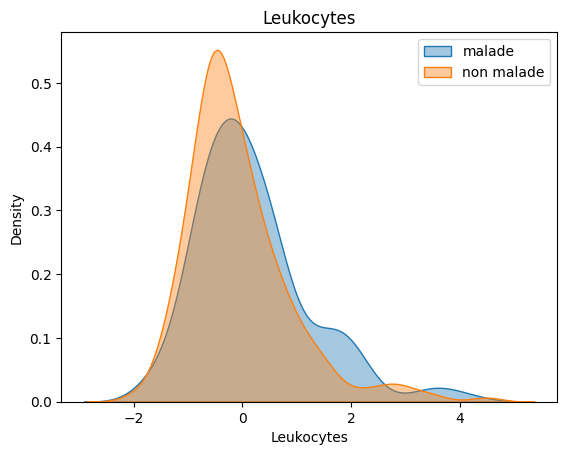

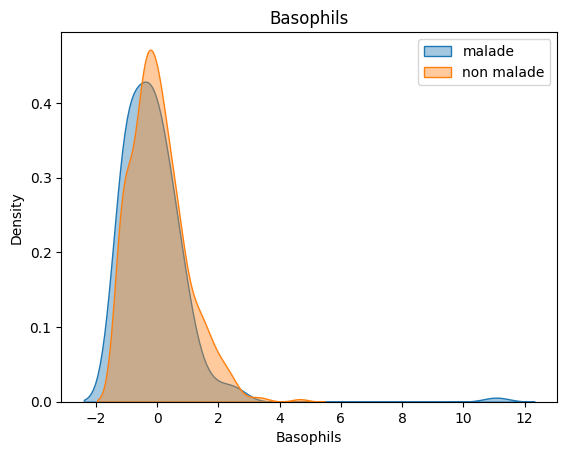

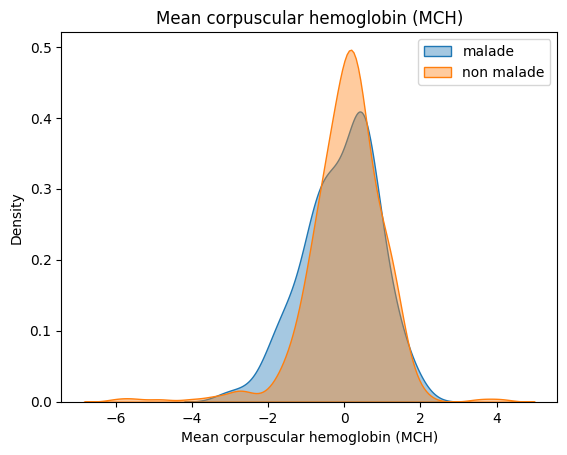

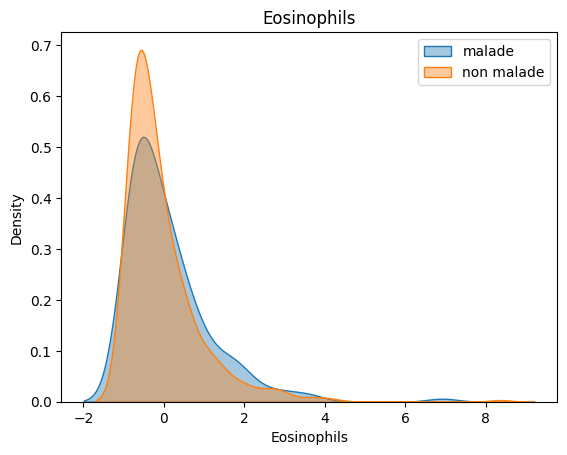

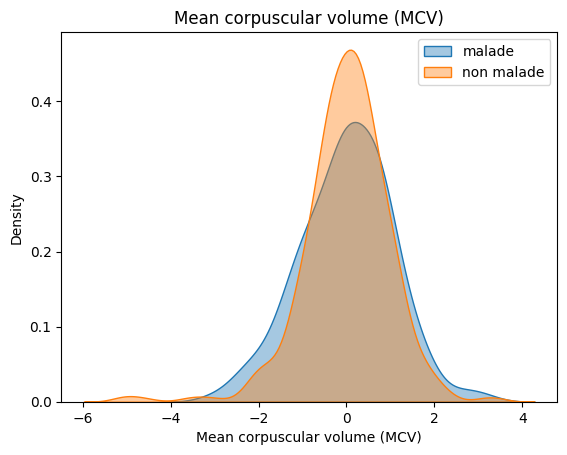

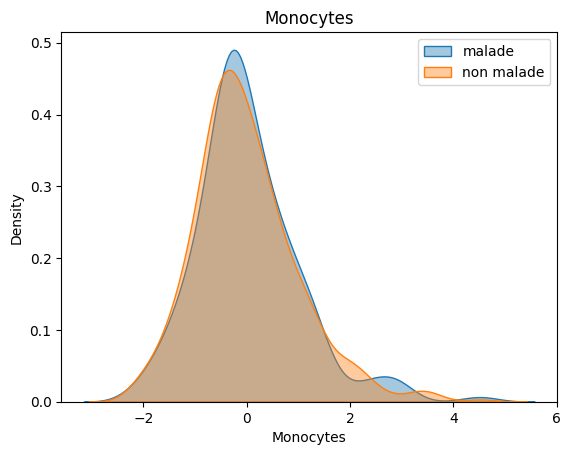

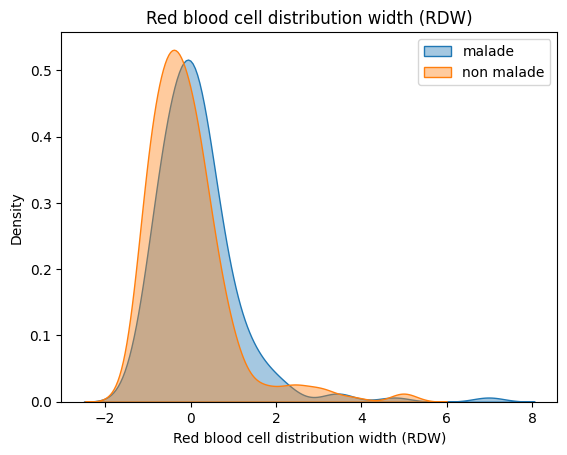

In [32]:
for col in blood_columns:
    plt.figure()
    sns.kdeplot(malade_df[col], label='malade', fill=True, alpha=0.4)
    sns.kdeplot(non_malade_df[col], label='non malade', fill=True, alpha=0.4)
    plt.title(col)
    plt.legend()
    plt.show()

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


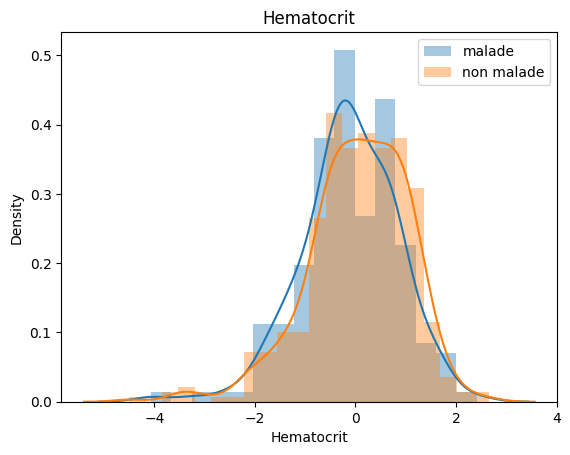

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


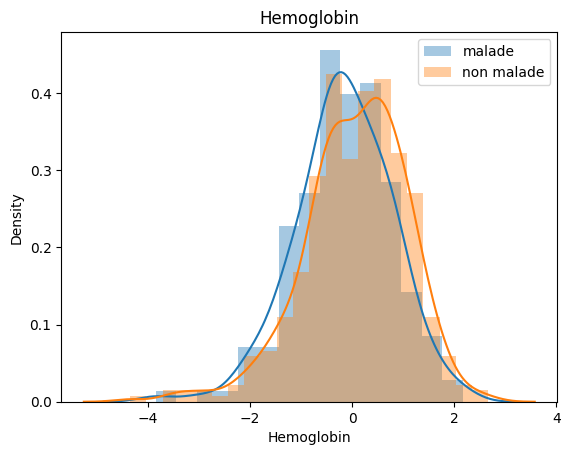

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


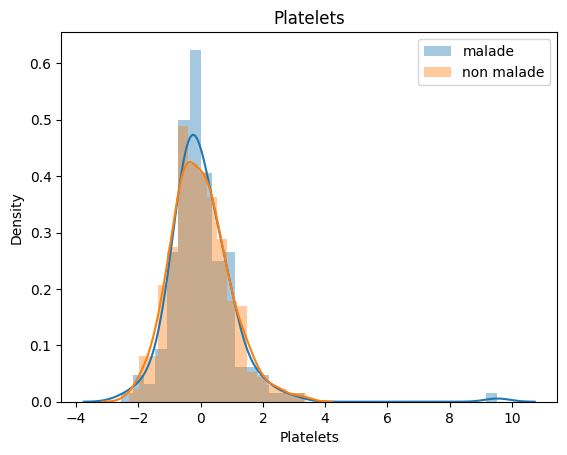

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


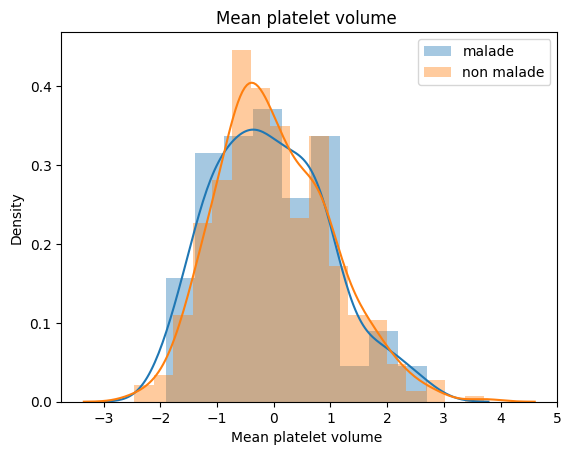

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


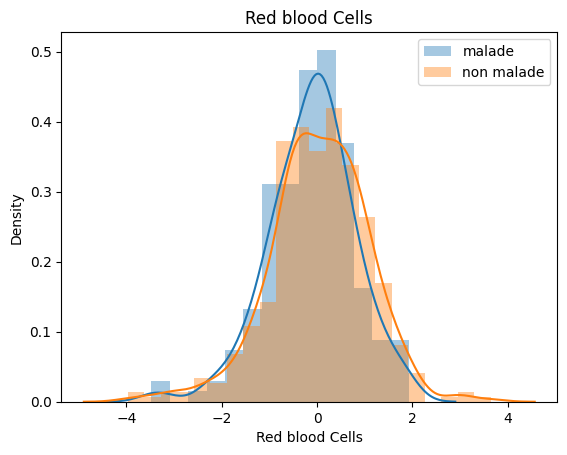

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


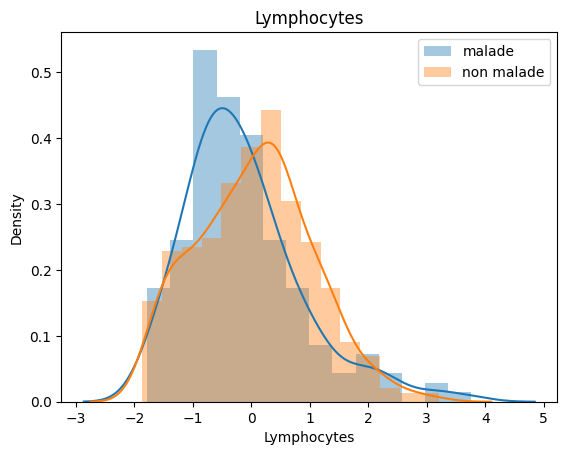

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


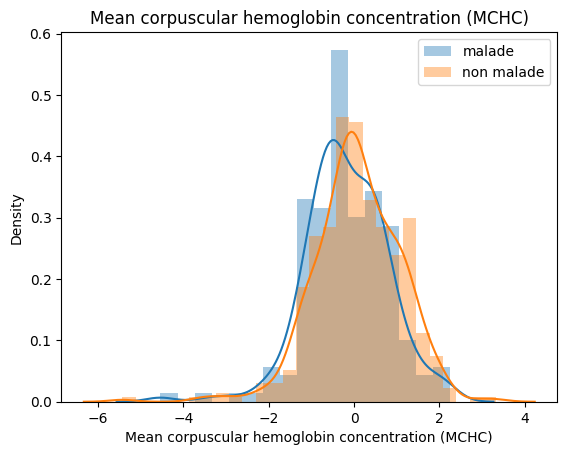

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


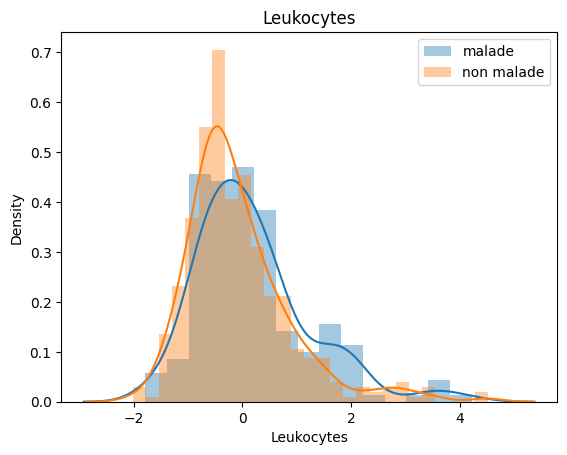

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


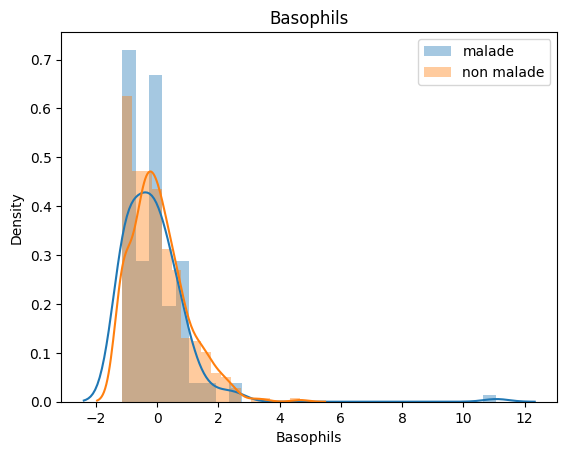

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


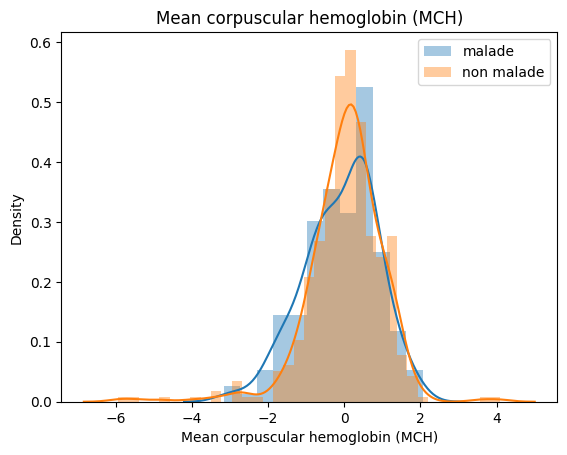

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


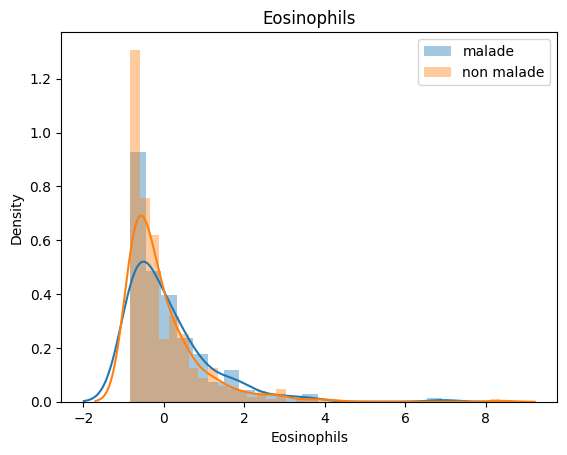

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


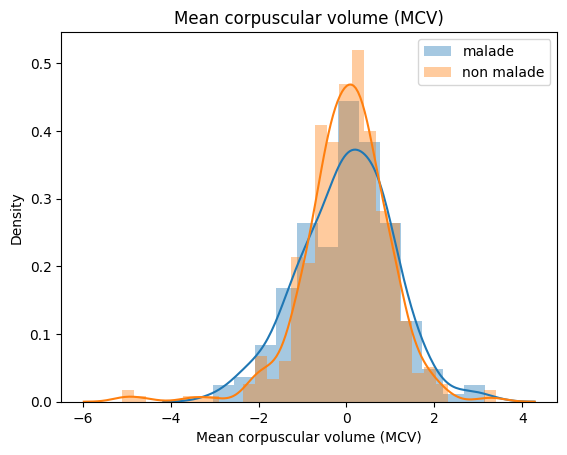

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


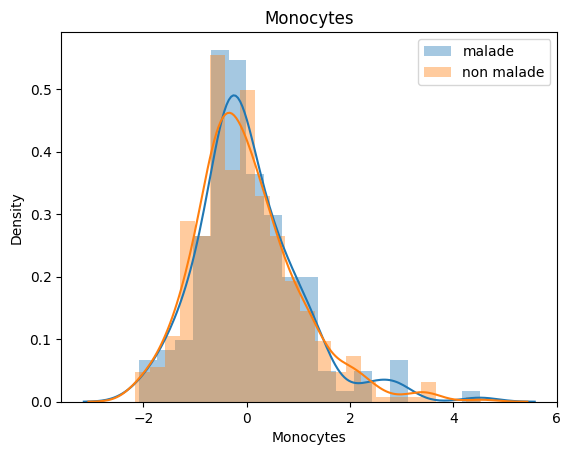

/tmp/ipykernel_1987/2769375595.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(malade_df[col], label='malade')
/tmp/ipykernel_1987/2769375595.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(non_malade_df[col], label='non malade')


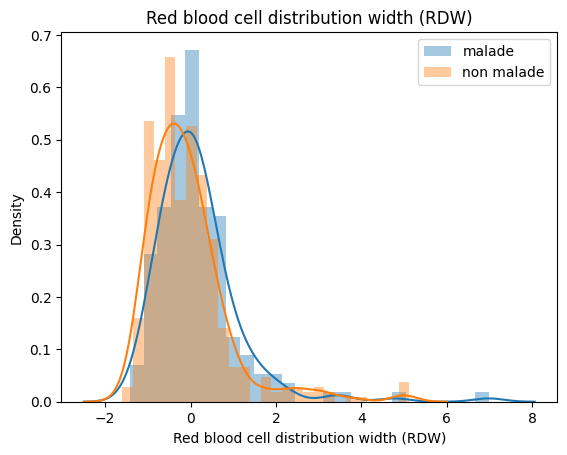

In [33]:
for col in blood_columns:
    plt.figure()
    sns.distplot(malade_df[col], label='malade')
    sns.distplot(non_malade_df[col], label='non malade')
    plt.title(col)
    plt.legend()
    plt.show()

Le constat : les taux sanguins diffèrent entre malades et non-malades. Mais
comme tu l'écris justement, ça reste une idée il faut la tester avec une
vraie hypothèse statistique, ce qu'on fait en section 5.

### Créer une variable : statut d'hospitalisation

In [34]:
def hospitalisation(row):
    if row['Patient addmited to regular ward (1=yes, 0=no)'] == 1:
        return 'surveillance'
    elif row['Patient addmited to semi-intensive unit (1=yes, 0=no)'] == 1:
        return 'soins semi intensifs'
    elif row['Patient addmited to intensive care unit (1=yes, 0=no)'] == 1:
        return 'soins intensifs'
    else:
        return 'inconnu'

df['statut'] = df.apply(hospitalisation, axis=1)
df['statut'].value_counts()

,count
statut,
inconnu,5474
surveillance,79
soins semi intensifs,50
soins intensifs,41


`apply` avec une fonction personnalisée fusionne trois colonnes en une seule
variable lisible le statut d'hospitalisation. C'est utile pour la tâche 2 du
défi : prédire dans quel service un patient ira.

Le constat : la relation hospitalisation / taux sanguins serait intéressante si
l'on voulait prédire le service d'admission d'un patient une piste pour la
seconde partie du projet.

## 5. Tester les hypothèses : le test de Student

L'EDA a produit des hypothèses. Une analyse sérieuse ne s'arrête pas à
« semble lié » elle teste. Le test de Student (*t-test*) compare les moyennes de
deux groupes et dit si leur différence est statistiquement significative.

### Les hypothèses à tester

Hypothèse nulle (H0) : les taux de Leukocytes, Monocytes, Platelets sont
égaux en moyenne chez les positifs et les négatifs.

Si le test rejette H0, c'est que la différence observée est réelle, pas due au
hasard et donc que ces variables sont vraiment liées au COVID.

### Équilibrer les groupes

Les positifs sont bien moins nombreux (10 %). Pour un test équitable, on tire un
échantillon de négatifs de la même taille.

In [35]:
from scipy.stats import ttest_ind

print('positifs :', positive_df.shape[0])
print('négatifs :', negative_df.shape[0])

# Échantillon équilibré de négatifs
balanced_neg = negative_df.sample(positive_df.shape[0], random_state=0)

positifs : 558
négatifs : 5086


`sample` tire au hasard autant de négatifs qu'il y a de positifs. Sans cet
équilibrage, le test serait biaisé par la taille très inégale des groupes.

### Le test

In [36]:
def test_student(col, alpha=0.02):
    stat, p = ttest_ind(
        balanced_neg[col].dropna(),
        positive_df[col].dropna())
    if p < alpha:
        return 'H0 rejetée, différence significative'
    else:
        return 'H0 conservée, pas de différence prouvée'

for col in blood_columns:
    print(f'{col:-<45} {test_student(col)}')

Hematocrit----------------------------------- H0 rejetée, différence significative
Hemoglobin----------------------------------- H0 rejetée, différence significative
Platelets------------------------------------ H0 rejetée, différence significative
Mean platelet volume ------------------------ H0 rejetée, différence significative
Red blood Cells------------------------------ H0 rejetée, différence significative
Lymphocytes---------------------------------- H0 conservée, pas de différence prouvée
Mean corpuscular hemoglobin concentration (MCHC) H0 conservée, pas de différence prouvée
Leukocytes----------------------------------- H0 rejetée, différence significative
Basophils------------------------------------ H0 conservée, pas de différence prouvée
Mean corpuscular hemoglobin (MCH)------------ H0 conservée, pas de différence prouvée
Eosinophils---------------------------------- H0 rejetée, différence significative
Mean corpuscular volume (MCV)---------------- H0 conservée, pas de diffé

Comment lire le résultat. Le test renvoie une *p-value* : la probabilité
d'observer une telle différence si H0 était vraie (moyennes égales).

Si `p < alpha` (ici 0,02), on rejette H0 : la différence est trop marquée pour
être due au hasard. La variable est significativement liée au COVID.

Si `p >= alpha`, on conserve H0 : on n'a pas de preuve suffisante d'une
différence.

`dropna()` est essentiel le test ne fonctionne pas avec des NaN, et ce jeu en
est plein.

L'aboutissement de l'EDA. Les hypothèses nées de l'observation visuelle sont
maintenant testées. Les variables qui rejettent H0 sont les candidates
sérieuses pour le modèle on est passé de « ça semble lié » à « c'est
statistiquement lié ». C'est la différence entre une intuition et une conclusion.

Une réserve de rigueur. Multiplier les tests augmente le risque de faux
positifs (un test sur 50 ressort « significatif » par hasard au seuil 0,02). Sur un
vrai projet, on corrige ce risque (correction de Bonferroni, par exemple). Ici,
l'essentiel est la démarche : observer, formuler, tester.

## 6. Mémo : la méthode EDA

### La check-list complète

Analyse de forme
1. Identifier la variable cible
2. Dimensions (lignes, colonnes)
3. Types de variables (`dtypes.value_counts()`)
4. Valeurs manquantes (heatmap + taux)

Analyse de fond
1. Visualiser la cible (équilibre des classes ?)
2. Comprendre chaque variable (distribution, sens)
3. Relations variables / cible (groupes positif vs négatif)
4. Relations variables / variables (corrélations)
5. Formuler des hypothèses
6. Les tester (t-test)

### Les outils clés

| Besoin | Code |
|---|---|
| Types | `df.dtypes.value_counts()` |
| Carte des NaN | `sns.heatmap(df.isna(), cbar=False)` |
| Taux de NaN | `df.isna().sum() / df.shape[0]` |
| Équilibre cible | `df[cible].value_counts(normalize=True)` |
| Comparer 2 groupes | `sns.kdeplot(...)` superposés |
| Croiser catégories | `pd.crosstab(...)` |
| Corrélations | `df.corr(numeric_only=True)` |
| Tester une différence | `ttest_ind(...)` |

### Les pièges rencontrés

| Situation | Ce qui se passe |
|---|---|
| `distplot` × 2 | figures séparées, pas de superposition |
| `corr()` sans `numeric_only` | `ValueError` sur le texte |
| Conclure sans tester | « semble lié » n'est pas « est lié » |
| Oublier `dropna()` avant t-test | échoue sur les NaN |
| Groupes déséquilibrés | test biaisé, il faut équilibrer |
| Interpréter une variable transformée | l'âge en quantile n'est pas l'âge |

## 7. Exercices

**Exercice 1**

Reproduis l'analyse de forme sur le dataset : affiche les dimensions, les types,
et le taux de valeurs manquantes des 10 colonnes les plus vides. Combien de
colonnes dépassent 90 % de NaN ?

**Exercice 2**

Pour les trois variables suspectées (Leukocytes, Monocytes, Platelets), applique
le test de Student et conclus : lesquelles sont significativement liées au COVID au
seuil de 0,02 ? Ton hypothèse visuelle est-elle confirmée ?

**Exercice 3**

Un collègue conclut « le faible âge protège du COVID » à partir du `countplot`
âge/cible. Explique en quoi cette conclusion est hâtive, en t'appuyant sur ce
qu'on ignore de la variable âge et du contexte du dataset.

## Pour continuer

Tu as mené une EDA complète sur des données médicales réelles la compétence la
plus recherchée en data science, car c'est elle qui oriente tout le reste. Un bon
modèle commence toujours par une bonne compréhension des données.

La suite du projet appliquera tout ce que tu as appris : nettoyer et imputer ce
jeu troué (notebooks 22.x), construire un pipeline honnête (validation stratifiée
vu le déséquilibre), et entraîner un modèle sans doute un ensemble (notebook
25) pour prédire le diagnostic. L'EDA t'a donné la carte ; reste à faire le
voyage.

In [37]:
# Exercice 1

In [38]:
import pandas as pd

data = pd.read_excel('dataset.xlsx')
df = data.copy()

# Dimensions
print('Dimensions :', df.shape)
print()

# Types
print('Types de variables :')
print(df.dtypes.value_counts())
print()

# Taux de valeurs manquantes, les 10 colonnes les plus vides
taux_manquant = df.isna().sum() / df.shape[0]
print('Les 10 colonnes les plus vides :')
print((taux_manquant.sort_values(ascending=False).head(10) * 100).round(1))
print()

# Combien dépassent 90 % de NaN
au_dessus_90 = (taux_manquant > 0.90).sum()
print(f'Colonnes avec plus de 90 % de NaN : {au_dessus_90} sur {df.shape[1]}')

Dimensions : (5644, 111)

Types de variables :
float64    70
object     37
int64       4
Name: count, dtype: int64

Les 10 colonnes les plus vides :
Mycoplasma pneumoniae                 100.0
Prothrombin time (PT), Activity       100.0
D-Dimer                               100.0
Urine - Sugar                         100.0
Partial thromboplastin time (PTT)     100.0
Urine - Nitrite                       100.0
Fio2 (venous blood gas analysis)      100.0
Vitamin B12                            99.9
Lipase dosage                          99.9
Albumin                                99.8
dtype: float64

Colonnes avec plus de 90 % de NaN : 72 sur 111


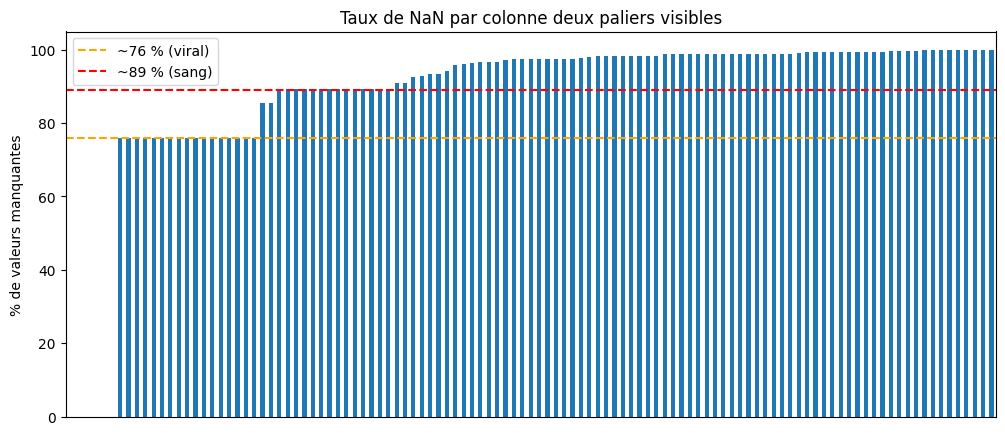

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
(taux_manquant.sort_values() * 100).plot(kind='bar')
plt.axhline(76, color='orange', linestyle='--', label='~76 % (viral)')
plt.axhline(89, color='red', linestyle='--', label='~89 % (sang)')
plt.ylabel('% de valeurs manquantes')
plt.legend()
plt.xticks([])
plt.title('Taux de NaN par colonne deux paliers visibles')
plt.show()

In [41]:
# Exerice 2

In [43]:
from scipy.stats import ttest_ind

positive_df = df[df['SARS-Cov-2 exam result'] == 'positive']
negative_df = df[df['SARS-Cov-2 exam result'] == 'negative']

# Échantillon équilibré de négatifs
balanced_neg = negative_df.sample(positive_df.shape[0], random_state=0)

# Les trois variables suspectées (attention aux noms exacts du dataset)
variables = ['Leukocytes', 'Monocytes', 'Platelets']

alpha = 0.02
print(f'Test de Student au seuil α = {alpha}\n')

for col in variables:
    stat, p = ttest_ind(
        balanced_neg[col].dropna(),
        positive_df[col].dropna())
    verdict = 'H0 REJETÉE, lié au COVID' if p < alpha else 'H0 conservée non prouvé'
    print(f'{col:<14} p = {p:.4f}   {verdict}')

Test de Student au seuil α = 0.02

Leukocytes     p = 0.0000   H0 REJETÉE, lié au COVID
Monocytes      p = 0.0050   H0 REJETÉE, lié au COVID
Platelets      p = 0.0000   H0 REJETÉE, lié au COVID


In [44]:
for col in variables:
    n_pos = positive_df[col].dropna().shape[0]
    n_neg = balanced_neg[col].dropna().shape[0]
    print(f'{col:<14} testé sur {n_pos} positifs et {n_neg} négatifs')

Leukocytes     testé sur 83 positifs et 61 négatifs
Monocytes      testé sur 83 positifs et 61 négatifs
Platelets      testé sur 83 positifs et 61 négatifs


In [45]:
# Exercice 3

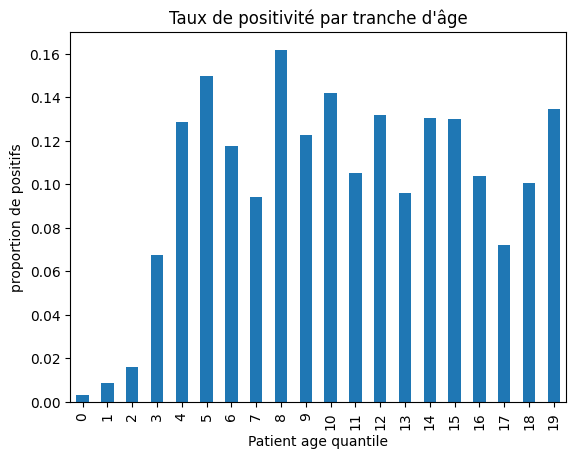

In [46]:
taux_par_age = df.groupby('Patient age quantile')['SARS-Cov-2 exam result'].apply(
    lambda x: (x == 'positive').mean())
taux_par_age.plot(kind='bar')
plt.ylabel('proportion de positifs')
plt.title('Taux de positivité par tranche d\'âge')
plt.show()